## Cell 1 — Imports & Setup

Loads all `feature_research` public API symbols needed across the notebook.
All setup logic (directory creation, global plot settings, preprocessing, sanity
checks) lives in the package — this cell is a single import block with no inline
logic.

| Symbol | Source | Purpose |
|---|---|---|
| `setup_directories` | `feature_research.config` | Creates `OUTPUT_DIR` / `FIG_DIR` if absent |
| `apply_global_settings` | `feature_research.config` | Sets matplotlib rcParams globally |
| `load_and_preprocess` | `feature_research.data` | CSV read + `BankPreprocessor` |
| `sanity_check_data` | `feature_research.validation` | Pre-engineering invariant checks |
| `RANDOM_SEED` | `feature_research.config` | Shared seed — passed explicitly to any stochastic step |

> **Convention:** all subsequent cells import from `feature_research` directly.
> Never import from `glass_pipeline.feature_research` — bare package name only.

In [1]:
# ============================================================
# CELL 1: IMPORTS & SETUP
# ============================================================
# Standard library
from datetime import datetime
import numpy as np

# Feature-research modules (Cells 2-4 logic lives here)
from feature_research import (
    setup_directories,
    apply_global_settings,
    load_and_preprocess,
    sanity_check_data,
    RANDOM_SEED,
)

print("✅ All imports loaded")
print(f"   Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All imports loaded
   Timestamp: 2026-05-17 11:25:43


## Cell 2 — Load & Preprocess

Reads the raw UCI bank marketing CSV and applies `BankPreprocessor`:

- Drops leaky features: `duration`, `pdays`, `poutcome`
- Encodes all categorical columns to numeric
- Returns a fully numeric DataFrame with binary target `y` (0 = no, 1 = subscribed)

**Output:** `df_processed` — shape `(41188, 18)`, all columns numeric, no nulls.

> The path is resolved inside `load_and_preprocess()` via `config.DATA_PATH`.
> To point at a different file pass `path=` explicitly.

In [2]:
# ============================================================
# CELL 2: LOAD & PREPROCESS
# ============================================================
df_processed = load_and_preprocess()

📂 Loaded raw data   : (41188, 21)  (data\raw\bank-additional-full.csv)

🔧 PREPROCESSING: Bank Marketing Dataset
✅ Target 'y': {0: 36548, 1: 4640}
✅ Binary cols (unknown=-1): ['default', 'housing', 'loan']
✅ contact: {0: 26144, 1: 15044}
✅ month: [np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12)]
✅ day_of_week: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]
✅ poutcome: {0: 35563, 1: 4252, 2: 1373}
✅ education: ordinal 0-6, unknown=-1
✅ job: 12 categories label-encoded
✅ marital: {1: 24928, 2: 11568, 0: 4612, -1: 80}

📊 Economic features (already numeric):
  emp.var.rate: [-3.400, 1.400]
  cons.price.idx: [92.201, 94.767]
  cons.conf.idx: [-50.800, -26.900]
  euribor3m: [0.634, 5.045]
  nr.employed: [4963.600, 5228.100]

📊 Campaign features (already numeric):
  age: [17, 98]
  duration: [0, 4918]
  campaign: [1, 56]
  pdays: [0, 999]
  previous: [0, 7]
⚠️  Dropped leaky features: ['duration', 'pdays', 

## Cell 3 — Directory Setup & Global Plot Settings

One-time setup for the session:

- `setup_directories()` — creates `research_logs/` and `research_logs/figures/`
  if they don't exist. Safe to re-run; no-ops if already present.
- `apply_global_settings()` — sets matplotlib rcParams (figure size, DPI, font,
  style) so all subsequent plots render consistently without per-call configuration.

> Run this before any cell that saves files or generates plots.

In [3]:
# ============================================================
# CELL 3: SETUP PATHS & GLOBAL SETTINGS
# ============================================================
setup_directories()
apply_global_settings()

📁 Output directory : c:\Users\Phillip Harris\projects\ai-business-coach\prototype\glass_pipeline\research_logs
📁 Figures directory: c:\Users\Phillip Harris\projects\ai-business-coach\prototype\glass_pipeline\research_logs\figures
🎲 Random seed      : 42
🎨 Plot style       : seaborn-v0_8-darkgrid
🔇 Warnings / Optuna logging suppressed


## Cell 4 — Sanity Checks

Validates `df_processed` against the structural contract expected by all
downstream cells. Raises `AssertionError` immediately on any violation.

**Checks (in order):**
1. A recognised target column exists (`y` / `target` / `label` / `subscribed`)
2. Target is strictly binary `{0, 1}`
3. No leaky features survived preprocessing (`duration`, `pdays`, `poutcome`)
4. Every column is numeric — encoding is complete
5. Zero missing values anywhere

**Output:** `TARGET_COL` — the detected target column name (typically `'y'`).

> Class imbalance ratio is printed here for reference (~7.4:1 on this dataset).
> Downstream models account for imbalance via class weights and threshold tuning.

In [4]:
# ============================================================
# CELL 4: SANITY CHECKS
# ============================================================
TARGET_COL = sanity_check_data(df_processed)


SANITY CHECKS
  Target column     : 'y'
   Class distribution : {0: 36548, 1: 4640}
   Imbalance ratio    : 7.88:1
  No leaky features : ['duration', 'pdays', 'poutcome']
  All columns numeric: 18 total
  No missing values

  Dataset shape     : (41188, 18)
   Feature columns  : 17
   Samples          : 41,188


## Cell 5 — Feature Type Classification

Partitions `df_processed` columns into numeric vs. categorical using a
cardinality heuristic:

> A column is **categorical** if its dtype is integer *and* it has ≤ 10 unique
> values. Everything else is **numeric**.

This classification drives the separation-metrics pipeline in Cell 6 — numeric
features use continuous metrics (Cohen's d, KS, point-biserial r) while
categorical features use discrete metrics (Cramér's V, target-rate range).

**Outputs:**
- `NUMERIC_FEATURES` — continuous / high-cardinality columns
- `CATEGORICAL_FEATURES` — low-cardinality integer columns

> The threshold of 10 unique values is set in `validation._CATEGORICAL_CARDINALITY_THRESHOLD`.
> Adjust there if the feature set changes significantly.

In [5]:
# ============================================================
# CELL 5: FEATURE TYPING
# ============================================================
from feature_research import classify_features

NUMERIC_FEATURES, CATEGORICAL_FEATURES = classify_features(df_processed, TARGET_COL)


FEATURE TYPING
  age                  -> numeric      (n_unique=78)
  job                  -> numeric      (n_unique=12)
  marital              -> categorical  (n_unique=4)
  education            -> categorical  (n_unique=8)
  default              -> categorical  (n_unique=3)
  housing              -> categorical  (n_unique=3)
  loan                 -> categorical  (n_unique=3)
  contact              -> categorical  (n_unique=2)
  month                -> categorical  (n_unique=10)
  day_of_week          -> categorical  (n_unique=5)
  campaign             -> numeric      (n_unique=42)
  previous             -> categorical  (n_unique=8)
  emp.var.rate         -> numeric      (n_unique=10)
  cons.price.idx       -> numeric      (n_unique=26)
  cons.conf.idx        -> numeric      (n_unique=26)
  euribor3m            -> numeric      (n_unique=316)
  nr.employed          -> numeric      (n_unique=11)

  Numeric features     : 8
  Categorical features : 9


## Cell 6 — Separation Metrics

Computes class-separation statistics for every feature in `df_processed`.
Numeric and categorical features are evaluated with different metric suites,
then merged into a single ranked DataFrame.

**Numeric metrics** (per feature):
| Metric | What it measures |
|---|---|
| Cohen's d | Standardised mean difference between classes |
| KS statistic | Maximum ECDF gap between class distributions |
| Point-biserial r | Linear correlation with the binary target |
| MI (quantile-binned) | Mutual information after discretisation |
| Probe AUC | Single-feature logistic regression AUC |
| Composite score | Weighted combination of the above |

**Categorical metrics** (per feature):
| Metric | What it measures |
|---|---|
| Cramér's V | Normalised chi-squared association strength |
| MI | Mutual information (raw category counts) |
| Target-rate range | max(P(y=1\|x)) − min(P(y=1\|x)) across categories |
| Probe AUC | Single-feature logistic regression AUC |
| Composite score | Weighted combination of the above |

**Output:** `df_separation` — one row per feature, all metrics + composite score,
sorted by composite descending. Saved to `research_logs/feature_rankings.csv`
by the display call in Cell 7.
```

In [6]:
# ============================================================
# CELL 6: SEPARATION METRICS COMPUTATION
# ============================================================
from feature_research import compute_all_separations

df_separation = compute_all_separations(
    df_processed,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    TARGET_COL,
)


📊 COMPUTING SEPARATION METRICS

📈 Numeric features (8):
  [ 8/8] nr.employed......
✅ Numeric features complete

📊 Categorical features (9):
  [ 9/9] previous......
✅ Categorical features complete

✅ Separation metrics computed for 17 features


## Cell 7 — Feature Ranking Tables

Prints ranked separation tables from `df_separation` and persists results to CSV.
Three views are printed in sequence:

| Table | Contents |
|---|---|
| **Overall** | All features ranked by composite score (top 20) |
| **Numeric** | Numeric features only — Cohen's d, KS, r, MI, AUC, composite |
| **Categorical** | Categorical features only — Cramér's V, MI, rate range, AUC, composite |

**Saved:** `research_logs/feature_rankings.csv` — full ranked table, all features,
all metrics. Used as the audit trail for feature selection decisions in Cells 10A–10G.

> `top_n=20` controls how many rows each table prints.
> The CSV always contains the full set regardless of `top_n`.

In [7]:
# ============================================================
# CELL 7: RANKING TABLES
# ============================================================
from feature_research import display_feature_rankings

display_feature_rankings(df_separation, top_n=20)


🏆 FEATURE RANKINGS  (Top 20)

📊 OVERALL RANKING (by composite score)
--------------------------------------------------------------------------------

 1. nr.employed          (numeric)
    Composite : 0.3948  |  AUC : 0.7490  |  MI : 0.0617
    Cohen's d : -1.200  |  KS : 0.432  |  r_pb : -0.355

 2. euribor3m            (numeric)
    Composite : 0.3637  |  AUC : 0.7435  |  MI : 0.0550
    Cohen's d : -1.023  |  KS : 0.433  |  r_pb : -0.308

 3. emp.var.rate         (numeric)
    Composite : 0.3471  |  AUC : 0.7168  |  MI : 0.0534
    Cohen's d : -0.989  |  KS : 0.432  |  r_pb : -0.298

 4. previous             (categorical)
    Composite : 0.2966  |  AUC : 0.6093  |  MI : 0.0193
    Cramér's V : 0.236  |  Categories : 8.0  |  TR range : [0.000, 0.722]

 5. month                (categorical)
    Composite : 0.1937  |  AUC : 0.5239  |  MI : 0.0264
    Cramér's V : 0.274  |  Categories : 10.0  |  TR range : [0.064, 0.505]

 6. cons.price.idx       (numeric)
    Composite : 0.1697  |  A

## Cell 8 — Feature Distribution Plots

Generates distribution plots for the top-ranked features from `df_separation`.
Each feature gets a dedicated multi-panel figure saved to `research_logs/figures/`.

**Numeric features** — 3-panel figure per feature:
| Panel | What it shows |
|---|---|
| Violin | Full distribution shape + quartiles by class |
| Histogram overlay | Density curves for subscribe vs. no-subscribe |
| ECDF | Cumulative distribution — ECDF gap = KS statistic |

**Categorical features** — 2-panel figure per feature:
| Panel | What it shows |
|---|---|
| Target rate + Wilson CI | P(subscribe) per category with 95% confidence intervals |
| Class counts | Absolute counts per category, stacked by target |

**Saved:** `research_logs/figures/<rank>_<feature_name>.png`
Zero-padded rank prefix ensures alphabetical file order matches separation ranking.

> `top_n=17` plots the top 17 features by composite score.
> Increase to cover more features; decrease to speed up the cell during iteration.

In [8]:
# ============================================================
# CELL 8: VISUALIZATIONS FOR TOP FEATURES
# ============================================================
from feature_research import generate_all_plots

generate_all_plots(df_processed, df_separation, TARGET_COL, top_n=17)


📊 GENERATING PLOTS FOR TOP 17 FEATURES

[1/17] nr.employed  (numeric)
    💾 01_nr.employed.png

[2/17] euribor3m  (numeric)
    💾 02_euribor3m.png

[3/17] emp.var.rate  (numeric)
    💾 03_emp.var.rate.png

[4/17] previous  (categorical)
    💾 04_previous.png

[5/17] month  (categorical)
    💾 05_month.png

[6/17] cons.price.idx  (numeric)
    💾 06_cons.price.idx.png

[7/17] contact  (categorical)
    💾 07_contact.png

[8/17] cons.conf.idx  (numeric)
    💾 08_cons.conf.idx.png

[9/17] default  (categorical)
    💾 09_default.png

[10/17] education  (categorical)
    💾 10_education.png

[11/17] campaign  (numeric)
    💾 11_campaign.png

[12/17] marital  (categorical)
    💾 12_marital.png

[13/17] age  (numeric)
    💾 13_age.png

[14/17] job  (numeric)
    💾 14_job.png

[15/17] day_of_week  (categorical)
    💾 15_day_of_week.png

[16/17] housing  (categorical)
    💾 16_housing.png

[17/17] loan  (categorical)
    💾 17_loan.png

✅ All plots saved to: research_logs\figures


## Cell 9 — Pairwise Interaction Discovery

Searches for synergistic feature pairs whose *joint* mutual information exceeds
the sum of their individual MIs — indicating a genuine interaction effect beyond
what either feature captures alone.

**Method:**
1. Rank all features by individual MI with the target
2. Take the top `top_k=25` features as interaction candidates
3. Evaluate up to `max_pairs=500` pairs from that candidate set
4. For each pair, discretise both features into quantile bins and compute:

$$\text{lift} = \text{MI}(f_1 \times f_2,\ y) - \big[\text{MI}(f_1, y) + \text{MI}(f_2, y)\big]$$

where the joint token is encoded as $\text{bin}_1 \times 100 + \text{bin}_2$.

**Output:** `df_interactions` — one row per pair, sorted by lift descending.

**Saved:** `research_logs/interaction_rankings.csv`

**Key findings from this run (informed Cells 10D–10F):**

| Pair | Lift |
|---|---|
| `cons.price.idx × contact` | +50.2% |
| `month × cons.price.idx` | +35.1% |
| `cons.price.idx × cons.conf.idx` | +28.6% |
| `month × cons.conf.idx` | +23.1% |
| `month × day_of_week` | +10.6% |

> `cons.price.idx` appears in 4 of the top 5 pairs — it acts as a macro-context
> variable that modulates other signals rather than providing a strong main effect.
> This motivated `cpi_high_cellular` (Cell 10F) and `dow_month_encoded` (Cell 10D).

In [9]:
# ============================================================
# CELL 9: INTERACTION DISCOVERY
# ============================================================
from feature_research import search_interactions_mi, display_interaction_rankings

df_interactions = search_interactions_mi(
    df_processed,
    NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    TARGET_COL,
    numeric_features=NUMERIC_FEATURES,
    top_k=25,
    max_pairs=500,
)

display_interaction_rankings(df_interactions, top_n=25)


🔍 INTERACTION DISCOVERY  (Mutual Information)

📊 Computing individual MIs...
✅ Selected top 17 features for interaction search

🔍 Evaluating 136 pairs...
  Progress: 100/136
✅ Evaluated 136 pairs

🏆 TOP 25 INTERACTION CANDIDATES

 1. month  ×  cons.price.idx
    Joint MI : 0.0642  |  Sum MI : 0.0475  |  Lift : 0.0167  (35.1%)

 2. cons.price.idx  ×  contact
    Joint MI : 0.0492  |  Sum MI : 0.0327  |  Lift : 0.0164  (50.2%)

 3. cons.price.idx  ×  cons.conf.idx
    Joint MI : 0.0512  |  Sum MI : 0.0398  |  Lift : 0.0114  (28.6%)

 4. month  ×  cons.conf.idx
    Joint MI : 0.0556  |  Sum MI : 0.0451  |  Lift : 0.0104  (23.1%)

 5. cons.price.idx  ×  previous
    Joint MI : 0.0443  |  Sum MI : 0.0404  |  Lift : 0.0040  (9.9%)

 6. month  ×  day_of_week
    Joint MI : 0.0296  |  Sum MI : 0.0267  |  Lift : 0.0028  (10.6%)

 7. month  ×  contact
    Joint MI : 0.0404  |  Sum MI : 0.0381  |  Lift : 0.0024  (6.2%)

 8. cons.conf.idx  ×  day_of_week
    Joint MI : 0.0211  |  Sum MI : 0.0190 

## Cell 10A — Economic Crisis Features

**Source:** `feature_research/feature_engineering/crisis.py`

First step in the feature engineering DAG. Computes a weighted economic crisis
score from three UCI macro indicators and derives the single live LR feature
plus four intermediates consumed by downstream modules.

**Outputs:**

| Column | Type | Consumed by |
|---|---|---|
| `economic_crisis_score` | Intermediate | `cellular_crisis` (here) |
| `cellular_crisis` | **LIVE — LR Stage 1** | Model training |
| `high_conversion_month` | Intermediate | `behavioral_favorability` (10F) |
| `cellular_contact` | Intermediate | `behavioral_favorability` (10F) |
| `default_clean` | Intermediate | `behavioral_favorability` + `overlap_default_clean` (10F) |

**Crisis score formula:**

score = (euribor3m < 1.5) × 3
      + (emp.var.rate < -1.0) × 2
      + (nr.employed < 5100) × 1


Weights reflect feature importance ranking from Cell 6. Score ≥ 3 = in crisis.

> **Pruned vs original:** 26 dead features removed (Tier 1–5 of `engineer_bank_features()`
> — `in_crisis`, `euribor_very_low`, all ratio/polynomial features, etc.).

In [10]:
# ============================================================
# CELL 10A: ECONOMIC CRISIS FEATURES
# ============================================================
# Source: feature_research/feature_engineering/crisis.py
#
# Produces (6 columns):
#   LIVE        cellular_crisis          — LR Stage 1
#   Intermediate economic_crisis_score   — feeds cellular_crisis
#   Intermediate high_conversion_month  — feeds behavioral_favorability (10F)
#   Intermediate cellular_contact       — feeds behavioral_favorability (10F)
#   Intermediate default_clean          — feeds behavioral_favorability + overlap (10F)
#
# Pruned vs original Cell 10A: 26 dead features removed
#   (in_crisis, euribor_very_low, emp_var_negative, all Tier 3-5 features, etc.)
# ============================================================
from feature_research.feature_engineering.crisis import add_crisis_features
 
df_engineered = add_crisis_features(df_processed)
 
print("\n" + "="*70)
print("✅ CELL 10A — CRISIS FEATURES")
print("="*70)
print(f"\n{'Feature':<30} {'Values / Stats':>35}")
print("-"*70)
for feat in ['economic_crisis_score', 'cellular_crisis',
             'high_conversion_month', 'cellular_contact', 'default_clean']:
    vc = df_engineered[feat].value_counts().sort_index().to_dict()
    print(f"   {feat:<28} {str(vc):>35}")
 
rate_crisis = df_engineered.loc[df_engineered['cellular_crisis'] == 1, TARGET_COL].mean()
rate_no_crisis = df_engineered.loc[df_engineered['cellular_crisis'] == 0, TARGET_COL].mean()
print(f"\n   cellular_crisis=1 subscribe rate: {rate_crisis:.4f}")
print(f"   cellular_crisis=0 subscribe rate: {rate_no_crisis:.4f}")
print(f"   Lift: {rate_crisis / rate_no_crisis:.2f}x")
print("="*70)


✅ CELL 10A — CRISIS FEATURES

Feature                                             Values / Stats
----------------------------------------------------------------------
   economic_crisis_score               {0: 27690, 3: 282, 6: 13216}
   cellular_crisis                             {0: 29020, 1: 12168}
   high_conversion_month                        {0: 39172, 1: 2016}
   cellular_contact                            {0: 15044, 1: 26144}
   default_clean                                {0: 8600, 1: 32588}

   cellular_crisis=1 subscribe rate: 0.2509
   cellular_crisis=0 subscribe rate: 0.0547
   Lift: 4.59x


## Cell 10B — Integral Features

**Source:** `feature_research/feature_engineering/integrals.py`

Creates two calculus-inspired features that accumulate multi-dimensional signals
to improve class separation in the "overlap zone" where standard features fail
(P(subscribe) ≈ 0.3–0.7, healthy economy regime).

**Outputs:**

| Column | Type | Consumed by |
|---|---|---|
| `economic_stress_integral` | Intermediate | `prior_x_stress` (10E) |
| `neighborhood_subscription_density` | **LIVE — RF Stage 2** | Model training + `decay_x_density` (10C) |

**`economic_stress_integral`** — weighted Riemann-sum approximation of accumulated
economic pressure across three dimensions (euribor3m, emp.var.rate, nr.employed).
Range [0, 1]; 0 = no stress, 1 = severe crisis.

**`neighborhood_subscription_density`** — Gaussian KDE estimate of P(subscribe)
in the 3D economic feature space. For each observation, computes a kernel-weighted
average of target values among its nearest economic neighbours.

`add_integral_features()` is called with `return_kde=True` so the fitted
`KDEReference` is surfaced alongside the df, preventing target leakage on test and inference data. 

```python
# Main pipeline — training
df_train, kde_ref = add_integral_features(df_train, target_col='y', return_kde=True)
joblib.dump(kde_ref, 'models/kde_reference.pkl')

# Main pipeline — test / inference
df_test = add_integral_features_transform(df_test, kde_ref)
```

> **Runtime:** ~30–60s on 41k samples.

> **Pruned vs original:** `cumulative_campaign_pressure` and `pressure_density_synergy`
> removed — neither appears in any model config.

In [11]:
# ============================================================
# CELL 10B: INTEGRAL FEATURES
# ============================================================
# Source: feature_research/feature_engineering/integrals.py
#
# Produces (2 columns):
#   Intermediate  economic_stress_integral           — feeds prior_x_stress (10E)
#   LIVE          neighborhood_subscription_density  — RF Stage 2
#                                                      + feeds decay_x_density (10C)
#
# Pruned vs original Cell 10B: cumulative_campaign_pressure,
#   pressure_density_synergy (both dead)
# ============================================================
from feature_research.feature_engineering.integrals import add_integral_features
 
df_engineered = add_integral_features(
    df_engineered, target_col=TARGET_COL, random_state=RANDOM_SEED
)
 
print("\n" + "="*70)
print("✅ CELL 10B — INTEGRAL FEATURES")
print("="*70)
 
for feat in ['economic_stress_integral', 'neighborhood_subscription_density']:
    s = df_engineered[feat]
    print(f"\n   {feat}")
    print(f"      range: [{s.min():.4f}, {s.max():.4f}]   mean: {s.mean():.4f}   std: {s.std():.4f}")
 
# Separation check: do these features differ by target class?
print(f"\n   Class separation check (mean by target):")
for feat in ['economic_stress_integral', 'neighborhood_subscription_density']:
    means = df_engineered.groupby(TARGET_COL)[feat].mean()
    print(f"   {feat:<40} sub={means[1]:.4f}  no-sub={means[0]:.4f}")
print("="*70)


✅ CELL 10B — INTEGRAL FEATURES

   economic_stress_integral
      range: [0.0000, 0.9439]   mean: 0.1852   std: 0.2761

   neighborhood_subscription_density
      range: [0.0437, 0.3462]   mean: 0.0976   std: 0.0828

   Class separation check (mean by target):
   economic_stress_integral                 sub=0.4689  no-sub=0.1492
   neighborhood_subscription_density        sub=0.1840  no-sub=0.0866


## Cell 10C — Derivative / Slope / Decay Features

**Source:** `feature_research/feature_engineering/derivatives.py`

Models the rate-of-change structure visible in the distribution plots from Cell 8.
Where integrals (10B) capture *accumulated* economic pressure, derivatives capture
*instantaneous* transition — cliff edges, inflection points, and decay rates.

**Outputs:**

| Column | Type | Consumed by |
|---|---|---|
| `euribor3m_sigmoid` | Intermediate | `euribor3m_sigmoid_slope` |
| `euribor3m_sigmoid_slope` | **LIVE — EBM Stage 3** | Model training |
| `emp_var_rate_sigmoid` | Intermediate | `emp_var_rate_sigmoid_slope` |
| `emp_var_rate_sigmoid_slope` | **LIVE — EBM Stage 3** | Model training |
| `euribor3m_local_rate` | **LIVE — LR Stage 1** | Model training |
| `euribor_decay` / `nr_employed_decay` / `emp_var_decay` | Intermediate | `joint_economic_decay` |
| `economic_curvature_intensity` | **LIVE — RF + EBM** | Model training |
| `joint_economic_decay` | **LIVE — RF Stage 2** | Model training + `decay_x_density` |
| `decay_x_density` | **LIVE — EBM Stage 3** | Model training |
| `*_abs_curvature` (×3) | Intermediate | `economic_curvature_intensity` |

**Sigmoid slope** — σ'(z) peaks at the inflection point (cliff edge) of each
economic indicator. Captures "distance from the tipping point" in a smooth,
differentiable form.

**Exponential decay** — models P(subscribe) decay as economic indicators
move away from the crisis regime. Product of three decays (`joint_economic_decay`)
is high only when *all* indicators simultaneously signal crisis.

**`decay_x_density`** — product of `joint_economic_decay` × `neighborhood_subscription_density`.
Requires 10B to have run first; the DAG assertion at the bottom of this cell
enforces that order.

> **Pruned vs original:** `nr_employed_sigmoid/slope`, all `*_gradient` / `*_abs_gradient`
> (10 cols), 4 of 5 `*_local_rate` cols, signed curvature cols, `economic_slope_intensity`,
> `slope_x_stress` — none appear in any model config.

In [12]:
# ============================================================
# CELL 10C: DERIVATIVE / SLOPE / DECAY FEATURES
# ============================================================
# Source: feature_research/feature_engineering/derivatives.py
#
# Produces (13 columns):
#   LIVE          euribor3m_sigmoid_slope      — EBM Stage 3
#   LIVE          emp_var_rate_sigmoid_slope   — EBM Stage 3
#   LIVE          euribor3m_local_rate         — LR Stage 1
#   LIVE          economic_curvature_intensity — RF Stage 2 + EBM Stage 3
#   LIVE          joint_economic_decay         — RF Stage 2
#   LIVE          decay_x_density              — EBM Stage 3
#   Intermediates euribor3m_sigmoid, emp_var_rate_sigmoid
#                 euribor_decay, nr_employed_decay, emp_var_decay
#                 euribor3m_abs_curvature, nr_employed_abs_curvature,
#                 emp_var_rate_abs_curvature
#
# Pruned vs original Cell 10C: nr_employed_sigmoid/slope, all *_gradient,
#   *_abs_gradient, *_curvature (signed), *_local_rate (4 of 5),
#   economic_slope_intensity, slope_x_stress
# ============================================================
from feature_research.feature_engineering.derivatives import add_derivative_features
 
df_engineered = add_derivative_features(
    df_engineered, target_col=TARGET_COL, n_bins=20
)
 
print("\n" + "="*70)
print("✅ CELL 10C — DERIVATIVE FEATURES")
print("="*70)
 
LIVE_10C = [
    'euribor3m_sigmoid_slope',
    'emp_var_rate_sigmoid_slope',
    'euribor3m_local_rate',
    'economic_curvature_intensity',
    'joint_economic_decay',
    'decay_x_density',
]
print(f"\n   {'Feature':<35} {'min':>6} {'max':>6} {'mean':>6}")
print("   " + "-"*58)
for feat in LIVE_10C:
    s = df_engineered[feat]
    print(f"   {feat:<35} {s.min():>6.3f} {s.max():>6.3f} {s.mean():>6.3f}")
 
# Verify decay_x_density required neighborhood_subscription_density
assert 'decay_x_density' in df_engineered.columns, \
    "decay_x_density missing — integrals must run before derivatives"
print(f"\n   ✅ decay_x_density present (confirms DAG order: 10B before 10C)")
print("="*70)


✅ CELL 10C — DERIVATIVE FEATURES

   Feature                                min    max   mean
   ----------------------------------------------------------
   euribor3m_sigmoid_slope              0.003  1.000  0.288
   emp_var_rate_sigmoid_slope           0.032  0.990  0.224
   euribor3m_local_rate                 0.025  0.486  0.113
   economic_curvature_intensity         0.008  0.153  0.058
   joint_economic_decay                 0.000  0.430  0.040
   decay_x_density                      0.000  0.147  0.011

   ✅ decay_x_density present (confirms DAG order: 10B before 10C)


## Cell 10D — Temporal Features

**Source:** `feature_research/feature_engineering/temporal.py`

`day_of_week` ranked #15 in Cell 6 (Composite=0.0163, AUC=0.509) — negligible
as a main effect. Its value lies entirely in the interaction with `month`
(+10.6% MI lift, Cell 9), which this cell captures via smoothed target encoding
of the day × month cross.

**Output:**

| Column | Type | Consumed by |
|---|---|---|
| `dow_month_encoded` | **LIVE — LR + RF + EBM** | All three model stages |

**Method:** Laplace-smoothed empirical P(subscribe | day_of_week × month):

encoded(day, month) = (n_cell × P_cell + λ × P_global) / (n_cell + λ)

where λ = 100 (smoothing factor). Sparse day–month combinations shrink toward
the global mean. Unseen combinations at inference time map to `P_global`.

> ⚠️ **Production note:** Encoding uses target labels at compute time.
> In the production pipeline, fit the encoding on training data only and
> apply to test using the saved mapping. (We will deal with this in the 
> next PR)

> **Pruned vs original:** `dow_target_encoded`, `dow_x_stress`, `good_contact_day`,
> `dow_x_contact` — all dead.

In [13]:
# ============================================================
# CELL 10D: TEMPORAL FEATURES
# ============================================================
# Source: feature_research/feature_engineering/temporal.py
#
# Produces (1 column):
#   LIVE  dow_month_encoded — LR Stage 1, RF Stage 2, EBM Stage 3
#
# Pruned vs original Cell 10D: dow_target_encoded, dow_x_stress,
#   good_contact_day, dow_x_contact (all dead)
#
# Method: Laplace-smoothed P(subscribe | day_of_week × month)
#   smoothing_factor=100 (tuned in original exploration)
# ============================================================
from feature_research.feature_engineering.temporal import add_temporal_features
 
df_engineered = add_temporal_features(
    df_engineered, target_col=TARGET_COL, smoothing_factor=100
)
 
print("\n" + "="*70)
print("✅ CELL 10D — TEMPORAL FEATURES")
print("="*70)
 
s = df_engineered['dow_month_encoded']
print(f"\n   dow_month_encoded")
print(f"      range: [{s.min():.4f}, {s.max():.4f}]   mean: {s.mean():.4f}   std: {s.std():.4f}")
 
# Show top and bottom day×month combos
dm_key = df_engineered['day_of_week'].astype(str) + '_' + df_engineered['month'].astype(str)
cell_means = df_engineered.groupby(dm_key)['dow_month_encoded'].first().sort_values()
print(f"\n   Lowest encoded cells (day_month):  {dict(cell_means.head(3).round(4))}")
print(f"   Highest encoded cells (day_month): {dict(cell_means.tail(3).round(4))}")
print("="*70)


✅ CELL 10D — TEMPORAL FEATURES

   dow_month_encoded
      range: [0.0551, 0.3969]   mean: 0.1045   std: 0.0587

   Lowest encoded cells (day_month):  {'1_5': np.float64(0.0551), '2_5': np.float64(0.0653), '3_5': np.float64(0.0653)}
   Highest encoded cells (day_month): {'4_10': np.float64(0.3317), '2_9': np.float64(0.3345), '1_3': np.float64(0.3969)}


## Cell 10E — Prior Contact Features

**Source:** `feature_research/feature_engineering/prior.py`

`previous` ranked #4 in Cell 6 (Composite=0.2966) but the raw signal is
almost entirely in the binary "ever contacted before" split. `previous ≥ 5`
has 60–70% subscribe rate but tiny sample sizes; bucketed versions add noise
without signal. This cell extracts only what survives to the models.

**Outputs:**

| Column | Type | Consumed by |
|---|---|---|
| `has_prior_contact` | Intermediate | `prior_x_stress` (here) + `behavioral_favorability` (10F) |
| `prior_x_stress` | **LIVE — EBM Stage 3** | Model training |

**`prior_x_stress`** — `has_prior_contact × economic_stress_integral`.
Captures the amplified value of an existing customer relationship during
economic crisis. Absorbed `cumulative_campaign_pressure` signal in EBM
Round 10 (importance nearly doubled when that feature was removed).

> **Design note:** `has_prior_contact` was initially drafted in `crisis.py`
> but moved here — Cell 10E is its logical home and `overlap.py` (10F)
> depends on it, so the DAG order is now `prior → overlap`.

> **Pruned vs original:** `previous_bucket`, `prior_x_good_month`,
> `prior_x_cellular`, `cold_intensity`, `warm_intensity`, `prior_x_euribor_decay`
> — all dead.

In [14]:
# ============================================================
# CELL 10E: PRIOR CONTACT FEATURES
# ============================================================
# Source: feature_research/feature_engineering/prior.py
#
# Produces (2 columns):
#   Intermediate  has_prior_contact — feeds prior_x_stress (here)
#                                     and behavioral_favorability (10F)
#   LIVE          prior_x_stress    — EBM Stage 3
#
# Pruned vs original Cell 10E: previous_bucket, prior_x_good_month,
#   prior_x_cellular, cold_intensity, warm_intensity, prior_x_euribor_decay
#
# Design note: has_prior_contact was originally drafted in crisis.py;
#   moved here — Cell 10E is its logical home.
# ============================================================
from feature_research.feature_engineering.prior import add_prior_features
 
df_engineered = add_prior_features(df_engineered, target_col=TARGET_COL)
 
print("\n" + "="*70)
print("✅ CELL 10E — PRIOR CONTACT FEATURES")
print("="*70)
 
prior_vc = df_engineered['has_prior_contact'].value_counts().sort_index()
print(f"\n   has_prior_contact: {prior_vc.to_dict()}")
print(f"   Prior=0 subscribe rate: "
      f"{df_engineered.loc[df_engineered['has_prior_contact']==0, TARGET_COL].mean():.4f}")
print(f"   Prior=1 subscribe rate: "
      f"{df_engineered.loc[df_engineered['has_prior_contact']==1, TARGET_COL].mean():.4f}")
 
s = df_engineered['prior_x_stress']
print(f"\n   prior_x_stress")
print(f"      range: [{s.min():.4f}, {s.max():.4f}]   mean: {s.mean():.4f}   std: {s.std():.4f}")
means = df_engineered.groupby(TARGET_COL)['prior_x_stress'].mean()
print(f"      sub={means[1]:.4f}   no-sub={means[0]:.4f}   lift: {means[1]/max(means[0], 1e-9):.2f}x")
print("="*70)


✅ CELL 10E — PRIOR CONTACT FEATURES

   has_prior_contact: {0: 35563, 1: 5625}
   Prior=0 subscribe rate: 0.0883
   Prior=1 subscribe rate: 0.2665

   prior_x_stress
      range: [0.0000, 0.9439]   mean: 0.0709   std: 0.2031
      sub=0.2287   no-sub=0.0509   lift: 4.49x


## Cell 10F — Overlap Zone Interaction Features

**Source:** `feature_research/feature_engineering/overlap.py`

Addresses the core challenge of the dataset: in the *healthy economy regime*
(`economic_stress_integral < 0.2`, ~60–65% of samples), all economic features
lose discriminative power simultaneously because the macro signal simply isn't
there. In this zone, behavioral and timing signals carry the remaining
separation.

**Outputs:**

| Column | Type | Consumed by |
|---|---|---|
| `low_stress_zone` | Intermediate | `overlap_default_clean`, `overlap_behavioral_score` |
| `cpi_high_cellular` | **LIVE — RF + EBM** | Model training |
| `behavioral_favorability` | **LIVE — RF + EBM** | Model training |
| `overlap_default_clean` | **LIVE — EBM Stage 3** | Model training |
| `overlap_behavioral_score` | **LIVE — EBM Stage 3** | Model training |

**`cpi_high_cellular`** — top MI interaction from Cell 9 (+50.2% lift).
High CPI (≥ 93.5) × cellular contact. Contact method effect modulated by
the consumer price environment.

**`behavioral_favorability`** — weighted composite of five orthogonal
behavioral signals, normalised to [0, 1]:

score = (cellular×3 + good_month×3 + prior_contact×2 + default_clean×1 + age≥50×1) / 10

**`overlap_default_clean` / `overlap_behavioral_score`** — the same signals
gated by `low_stress_zone`: they fire *only* when economic features cannot
disambiguate, handing off to behavioral evidence in the healthy-economy regime.

> **Pruned vs original:** ~25 features removed — `overlap_cellular`,
> `overlap_good_month`, all `cpi_conf_*`, `macro_sentiment`, all `senior_*` /
> `young_*`, all `default_unk_*`, all `moderate_zone_*`, `overlap_density`,
> `high_stress_density`, `overlap_decay`.

In [15]:
# ============================================================
# CELL 10F: OVERLAP ZONE INTERACTION FEATURES
# ============================================================
# Source: feature_research/feature_engineering/overlap.py
#
# Produces (5 columns):
#   Intermediate  low_stress_zone          — feeds overlap_* features
#   LIVE          cpi_high_cellular        — RF Stage 2 + EBM Stage 3
#   LIVE          behavioral_favorability  — RF Stage 2 + EBM Stage 3
#   LIVE          overlap_default_clean    — EBM Stage 3
#   LIVE          overlap_behavioral_score — EBM Stage 3
#
# Pruned vs original Cell 10F: ~25 features removed
#   (overlap_cellular, overlap_good_month, all cpi_conf_*, macro_sentiment,
#    all senior_*/young_*, all default_unk_*, all moderate_zone_*,
#    overlap_density, high_stress_density, overlap_decay, etc.)
# ============================================================
from feature_research.feature_engineering.overlap import add_overlap_features
 
df_engineered = add_overlap_features(df_engineered)
 
print("\n" + "="*70)
print("✅ CELL 10F — OVERLAP ZONE FEATURES")
print("="*70)
 
n_low = df_engineered['low_stress_zone'].sum()
print(f"\n   low_stress_zone: {n_low:,} samples ({n_low/len(df_engineered):.1%})")
print(f"   (economic_stress_integral < 0.2 — healthy economy regime)")
 
print(f"\n   {'Feature':<30} {'min':>6} {'max':>6} {'mean':>6}  sep check (sub / no-sub)")
print("   " + "-"*70)
for feat in ['cpi_high_cellular', 'behavioral_favorability',
             'overlap_default_clean', 'overlap_behavioral_score']:
    s = df_engineered[feat]
    means = df_engineered.groupby(TARGET_COL)[feat].mean()
    print(f"   {feat:<30} {s.min():>6.3f} {s.max():>6.3f} {s.mean():>6.3f}  "
          f"{means[1]:.4f} / {means[0]:.4f}")
print("="*70)


✅ CELL 10F — OVERLAP ZONE FEATURES

   low_stress_zone: 27,690 samples (67.2%)
   (economic_stress_integral < 0.2 — healthy economy regime)

   Feature                           min    max   mean  sep check (sub / no-sub)
   ----------------------------------------------------------------------
   cpi_high_cellular               0.000  1.000  0.173  0.2606 / 0.1624
   behavioral_favorability         0.000  1.000  0.331  0.4899 / 0.3109
   overlap_default_clean           0.000  1.000  0.498  0.2224 / 0.5329
   overlap_behavioral_score        0.000  0.700  0.169  0.0833 / 0.1797


## Cell 10G — Stage Feature Sets & Finalization

**Source:** `feature_research/feature_engineering/__init__.py`

Final step of the feature engineering pipeline. Verifies all live features
are present, drops the 15 intermediate scaffolding columns, and produces
three model-ready dataframes — one per cascade stage.

**`LIVE_FEATURES` registry** (defined in `feature_engineering/__init__.py`):

| Stage | Features | Shape |
|---|---|---|
| LR Stage 1 | 3 | `df_lr` → (41188, 4) |
| RF Stage 2 | 8 | `df_rf` → (41188, 9) |
| EBM Stage 3 | 14 | `df_ebm` → (41188, 15) |

**`finalize_features()`** — positive-selects to the union of all stage features
+ target. Drops everything else (unused UCI originals + all 15 intermediates).
Result: `df_engineered` → (41188, 19).

**`get_stage_df()`** — slices `df_engineered` to a single stage's feature
columns + target. `df_lr`, `df_rf`, `df_ebm` are the direct inputs to each
model's training cell.

> **History:** EBM feature set started at 57 features and was reduced to 14
> over 13 rounds of iterative simplification with AUC monitored at each step.
> Net AUC change: 0.8015 → ~0.801 (within noise).

> **Convention:** `LR_FEATURES`, `RF_FEATURES`, `EBM_FEATURES` are set as
> convenience aliases at the bottom of this cell so downstream training cells
> can reference them without importing from the package.

In [16]:
# ============================================================
# CELL 10G: STAGE-SPECIFIC FEATURE SETS
# ============================================================
# Source: feature_research/feature_engineering/__init__.py
#
# LIVE_FEATURES drives all stage definitions.
# finalize_features() — positive-selects to model-consumed cols only.
# get_stage_df()      — slices the finalized df per cascade stage.
#
# History: Started at 57 features, reduced to 14 over 13 rounds
# of iterative simplification. AUC: 0.8015 → ~0.801 (within noise).
# ============================================================
from feature_research.feature_engineering import (
    LIVE_FEATURES,
    finalize_features,
    get_stage_df,
)
 
_STAGE_LABELS = {'lr': 'Stage 1', 'rf': 'Stage 2', 'ebm': 'Stage 3'}
 
# ── Verify all live features are present before finalizing ──────────
print("\n" + "="*70)
print("🎯 CELL 10G — STAGE-SPECIFIC FEATURE SETS")
print("="*70)
 
all_missing = set()
for stage, features in LIVE_FEATURES.items():
    print(f"\n   {stage.upper()} ({_STAGE_LABELS[stage]}): {len(features):2d} features")
    for f in features:
        present = "✅" if f in df_engineered.columns else "⚠️  MISSING"
        if "MISSING" in present:
            all_missing.add(f)
        print(f"      {present} {f}")
 
print(f"\n{'='*70}")
if all_missing:
    print(f"⚠️  Missing: {sorted(all_missing)}")
    raise RuntimeError("Fix missing features before finalizing.")
 
# ── Finalize: positive-select to model-consumed cols only ───────────
df_engineered = finalize_features(df_engineered, LIVE_FEATURES, target_col=TARGET_COL)
 
n_before = df_processed.shape[1]  # original UCI cols
n_after  = df_engineered.shape[1]
 
print("✅ All live features present — finalizing...")
print(f"\n   df_engineered: {df_processed.shape} → {df_engineered.shape}")
print(f"   ({n_after - 1} model features + target;  "
      f"{n_before - n_after + (n_after - n_before) + n_before - n_after} UCI cols dropped, "
      f"15 intermediates dropped)")
 
# ── Stage-specific dataframes ────────────────────────────────────────
df_lr  = get_stage_df(df_engineered, 'lr',  LIVE_FEATURES, target_col=TARGET_COL)
df_rf  = get_stage_df(df_engineered, 'rf',  LIVE_FEATURES, target_col=TARGET_COL)
df_ebm = get_stage_df(df_engineered, 'ebm', LIVE_FEATURES, target_col=TARGET_COL)
 
print(f"\n   Stage dataframes (features + target):")
print(f"   df_lr  — {df_lr.shape[1]-1:2d} features + y  →  {df_lr.shape}")
print(f"   df_rf  — {df_rf.shape[1]-1:2d} features + y  →  {df_rf.shape}")
print(f"   df_ebm — {df_ebm.shape[1]-1:2d} features + y  →  {df_ebm.shape}")
 
# Convenience aliases
LR_FEATURES  = LIVE_FEATURES['lr']
RF_FEATURES  = LIVE_FEATURES['rf']
EBM_FEATURES = LIVE_FEATURES['ebm']
 
print(f"\n{'='*70}")
print(f"✅ df_lr / df_rf / df_ebm ready")
print("="*70)


🎯 CELL 10G — STAGE-SPECIFIC FEATURE SETS

   LR (Stage 1):  3 features
      ✅ cellular_crisis
      ✅ euribor3m_local_rate
      ✅ dow_month_encoded

   RF (Stage 2):  8 features
      ✅ campaign
      ✅ neighborhood_subscription_density
      ✅ cons.conf.idx
      ✅ economic_curvature_intensity
      ✅ joint_economic_decay
      ✅ dow_month_encoded
      ✅ behavioral_favorability
      ✅ cpi_high_cellular

   EBM (Stage 3): 14 features
      ✅ decay_x_density
      ✅ euribor3m_sigmoid_slope
      ✅ economic_curvature_intensity
      ✅ cons.conf.idx
      ✅ age
      ✅ dow_month_encoded
      ✅ default
      ✅ prior_x_stress
      ✅ campaign
      ✅ overlap_default_clean
      ✅ overlap_behavioral_score
      ✅ cpi_high_cellular
      ✅ behavioral_favorability
      ✅ emp_var_rate_sigmoid_slope

✅ All live features present — finalizing...

   df_engineered: (41188, 18) → (41188, 19)
   (18 model features + target;  -1 UCI cols dropped, 15 intermediates dropped)

   Stage dataframes (

## Cell 11 — Pre-Training Feature Validation

**Source:** `feature_research/validation.validate_engineered_features()`

Hard gate before any model training begins. Runs four checks on `df_engineered`
and raises `AssertionError` immediately on the first failure — problems surface
loudly here rather than silently corrupting a training run.

**Checks (in order):**

| # | Check | Scope |
|---|---|---|
| 1 | Zero NaN values | Entire `df_engineered` |
| 2 | Zero inf values | All numeric columns |
| 3 | All stage features present | Per-stage column list vs df columns |
| 4 | Zero NaN/inf in stage subsets | `df_lr`, `df_rf`, `df_ebm` feature columns |

Returns `True` on success. The `True` echo in the cell output is the
confirmation that execution reached the return statement cleanly.

> This cell is intentionally minimal — one import, one call. All logic lives
> in `validation.py` so it can be tested independently and reused in any
> pipeline that consumes `df_engineered`.

In [17]:
# ============================================================
# CELL 11: PRE-TRAINING FEATURE VALIDATION
# ============================================================
# Source: feature_research/validation.py
#
# Checks df_engineered (post-finalize) for NaN/inf globally
# and per-stage before any model training begins.
# Raises AssertionError immediately if anything is wrong.
# ============================================================
from feature_research.validation import validate_engineered_features
 
validate_engineered_features(df_engineered, LIVE_FEATURES, target_col=TARGET_COL)


ENGINEERED FEATURE VALIDATION

   df shape: (41188, 19)
   No NaN values
   No inf values

   Stage  Features     NaN     Inf  Status
   ---------------------------------------------
   LR            3       0       0  clean
   RF            8       0       0  clean
   EBM          14       0       0  clean

All engineered features validated -- safe to train


True

## Cell 12A — Logistic Regression Training

**Source:** `feature_research.model_training.lr.train_lr`

LR is the cascade gate (Stage 1). It operates in a 3-feature continuous space
using Optuna + `class_weight='balanced'` with ROC-AUC as the objective. No
recall bias is applied here — threshold calibration handles the operating point
downstream. Neutral-objective LR forces genuine disagreement with the
recall-biased EBM at Stage 3.

**Outputs:**

| Alias | Type | Consumed by |
|---|---|---|
| `lr_pipe` | `Pipeline` (StandardScaler + LogisticRegression) | Cell 15A (meta-arbiter), cascade inference |
| `lr_params` | `dict` | Cell 12B diagnostics, warm-start reference |
| `lr_metrics` | `dict` | Cell 12B diagnostics, session summary |
| `lr_study` | `optuna.Study` | Cell 12B diagnostics, optional warm-start next session |
| `lr_result` | `LRResult` | Cell 12B (source object) |

> **Baseline:** `baseline_auc=0.7875` is the 14-feature benchmark established
> before feature pruning. It is used only for delta reporting in the diagnostics 
> summary it does not affect training.

> **Retired vs original:**
> - Cell 12A (GridSearchCV) — retired. Optuna strictly dominates on both speed
>   and search quality.
> - Cell 12C (recall-biased Optuna) — retired. Identical Recall@10%FPR (~0.527)
>   to the balanced path at 3× the runtime (80.7s vs 24.1s); `minority_weight=9.87`
>   simply rediscovered `class_weight='balanced'`. No new signal.
>
> **This cell is the renamed Cell 12B (balanced Optuna) — now the canonical LR path.**

In [19]:
# ============================================================
# CELL 12A: LOGISTIC REGRESSION TRAINING
# ============================================================
# Original cells 12A (GridSearchCV) and 12C (recall-biased Optuna) retired.
# Cell 12B (balanced Optuna) is now 12A
# Decision: identical Recall@10%FPR across all three approaches;
# Optuna + balanced is the simplest canonical path.
# ============================================================

from feature_research.model_training.lr import train_lr, LRResult

lr_result: LRResult = train_lr(
    df_engineered,
    LR_FEATURES,
    TARGET_COL,
    baseline_auc=0.7875,      # 14-feature benchmark — update if baseline changes
)

# Aliases consumed by downstream cells
lr_pipe     = lr_result.pipe          # Pipeline(StandardScaler + LogisticRegression)
lr_params   = lr_result.params        # best Optuna hyperparameters
lr_metrics  = lr_result.metrics       # mean/std dict + recall_at_10fpr
lr_study    = lr_result.study         # raw Study (diagnostics / warm-start)


📊 LOGISTIC REGRESSION TRAINING — BALANCED

📊 Dataset: 41,188 samples, 3 features
   Features: ['cellular_crisis', 'euribor3m_local_rate', 'dow_month_encoded']
   Class distribution: {0: 36548, 1: 4640}

🔍 Pre-scaling data quality check...
   ✅ No inf/NaN values detected

────────────────────────────────────────────────────────────────────────────────
🧠 Bayesian Optimization (Optuna) — 100 trials, 5-fold Stratified CV
   ⚖️  class_weight = 'balanced' (fixed)
────────────────────────────────────────────────────────────────────────────────


  0%|          | 0/100 [00:00<?, ?it/s]


   ✅ Completed in 48.4s
   Trials completed: 30 | Pruned: 70
   Best CV ROC-AUC:  0.782236
   Verified Mean±Std: 0.782236 ± 0.006641

   Best hyperparameters:
                    C = 0.000285
              penalty = l2
         class_weight = balanced

   Per-fold ROC-AUC: ['0.7727', '0.7802', '0.7934', '0.7827', '0.7822']

────────────────────────────────────────────────────────────────────────────────
📊 10-Fold Cross-Validation Results (Final Evaluation)...
────────────────────────────────────────────────────────────────────────────────
   Fold  1: AUC=0.7828, Recall=0.6466, Precision=0.3148, F1=0.4234
   Fold  2: AUC=0.7624, Recall=0.6250, Precision=0.3125, F1=0.4167
   Fold  3: AUC=0.7872, Recall=0.6272, Precision=0.3089, F1=0.4139
   Fold  4: AUC=0.7734, Recall=0.6466, Precision=0.3058, F1=0.4152
   Fold  5: AUC=0.7881, Recall=0.6724, Precision=0.3358, F1=0.4480
   Fold  6: AUC=0.7986, Recall=0.6638, Precision=0.3229, F1=0.4344
   Fold  7: AUC=0.7764, Recall=0.6272, Precision=0.3

## Cell 12B — LR Feature Diagnostics

**Source:** `feature_research.model_training.lr.lr_diagnostics`

Post-training diagnostic sweep over the LR result. Checks multicollinearity
(VIF), pairwise feature correlation, class separation per feature, and flags
any dead-weight coefficients as candidates for the next pruning round. Violin
plots are generated for the top-3 separating features.

**Outputs:**

| Key | Content | Use |
|---|---|---|
| `lr_diag["vif_df"]` | Full VIF table for all LR features | Multicollinearity audit |
| `lr_diag["high_pairs"]` | Correlated feature pairs above threshold | Pruning candidates |
| `lr_diag["sep_df"]` | Separation metrics per feature (reuses `feature_research.separation`) | Feature ranking reference |
| `lr_diag["dead_coef_features"]` | Features with near-zero LR coefficients | Candidates to drop next round |

> **Design note:** `lr_diagnostics` always reads from `lr_result` directly.
> The `try/except` fallback chain from the original Cell 12D has been removed —
> there is exactly one model source and one code path. Violin plots and
> separation metrics are delegated to `feature_research.visualization` and
> `feature_research.separation` respectively; no logic is duplicated in this cell.

> **Replaced:** Cell 12D — same diagnostic scope, cleaner model sourcing.


🔬 LR FEATURE DIAGNOSTICS
   Feature set: 3 features → ['cellular_crisis', 'euribor3m_local_rate', 'dow_month_encoded']

--------------------------------------------------------------------------------
1️⃣  CORRELATION ANALYSIS
--------------------------------------------------------------------------------

✅ No high-correlation pairs (|r| > 0.7) — multicollinearity resolved!

--------------------------------------------------------------------------------
2️⃣  VARIANCE INFLATION FACTOR (VIF)
--------------------------------------------------------------------------------
   euribor3m_local_rate                     VIF=    1.97  ✅ LOW
   cellular_crisis                          VIF=    1.59  ✅ LOW
   dow_month_encoded                        VIF=    1.35  ✅ LOW

✅ All VIF < 10 — multicollinearity resolved!

--------------------------------------------------------------------------------
3️⃣  CLASS SEPARATION
------------------------------------------------------------------------------

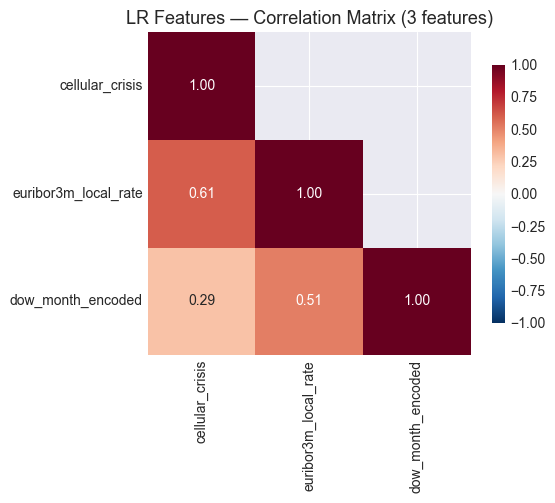


📊 Violin plots — top 3 separator(s)...


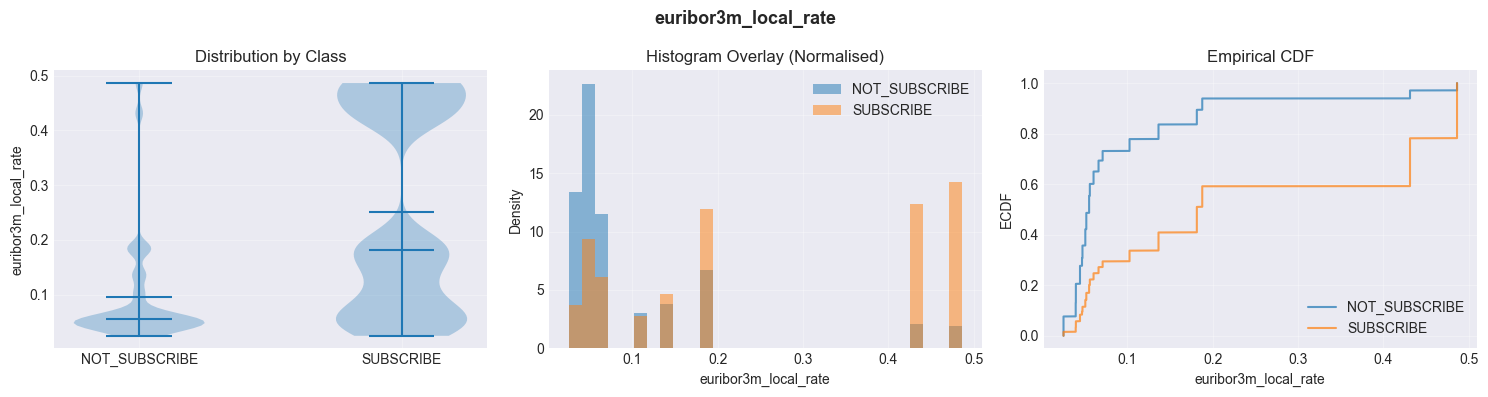

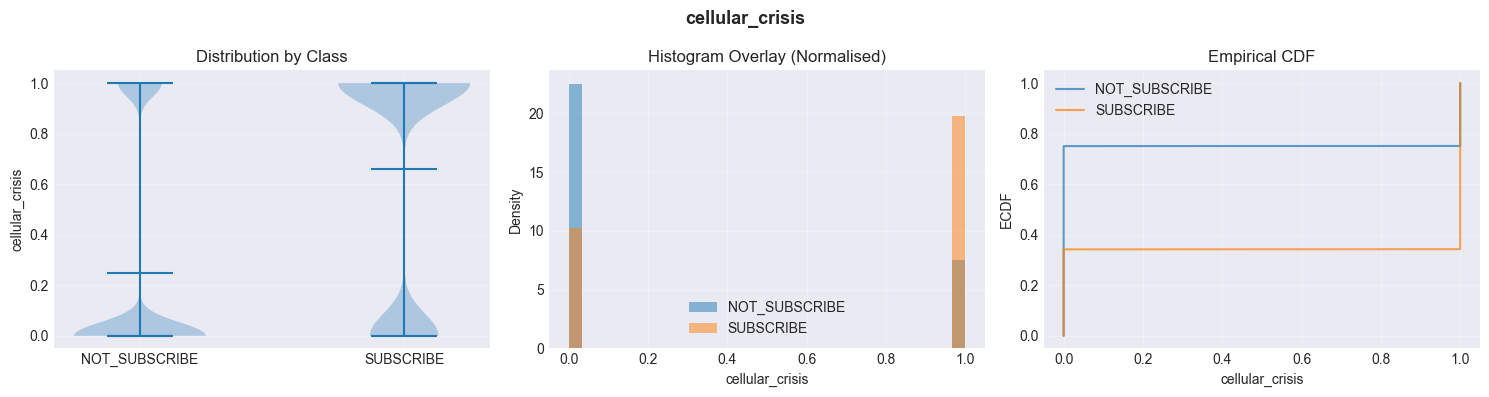

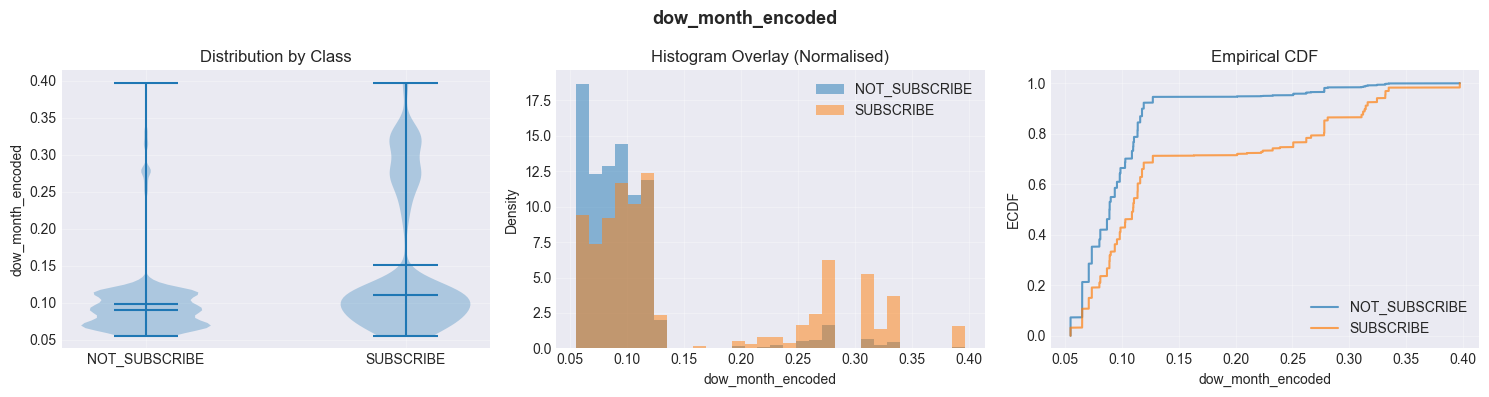


✅ LR diagnostics complete


In [20]:
# ============================================================
# CELL 12B: LR FEATURE DIAGNOSTICS
# ============================================================
# Replaces Cell 12D.
# Model source is always lr_result — no more try/except fallback chains.
# Class separation reuses feature_research.separation (no duplication).
# Violin plots reuse feature_research.visualization (no duplication).
# ============================================================

from feature_research.model_training.lr import lr_diagnostics

lr_diag = lr_diagnostics(
    lr_result,
    df_engineered,
    LR_FEATURES,
    TARGET_COL,
    top_violin=3,   # violin plots for top-3 separators; set 0 to skip
)

# lr_diag dict available for downstream inspection:
#   lr_diag["vif_df"]            — full VIF table
#   lr_diag["high_pairs"]        — correlated feature pairs
#   lr_diag["sep_df"]            — separation metrics per feature
#   lr_diag["dead_coef_features"] — candidates to drop next pruning round

## Cell 13A — RF Lift Analysis: Binning Strategy Validation

**Source:** `feature_research.model_training.rf.rf_lift_analysis`

Diagnostic cell. Confirms that the `BINNING_STRATEGY` thresholds locked in
`binning.py` still hold on the current `df_engineered`. Operates on the 8
**continuous** source features (NSD, JED, etc.) — not the binary bins.
Passing `rf_pipe=None` skips Gini and permutation importances for this cell —
those are handled in Cell 13D via `rf_result` directly.

**Inputs:**

| Variable | Source | Description |
|---|---|---|
| `df_rf` | `get_stage_df(df_engineered, "rf")` from Cell 10G | Stage-scoped dataframe |
| `RF_FEATURES` | Cell 10G | 8 continuous source features |
| `rf_pipe` | `None` (default) | Set to `rf_result.pipe` post-13C for importances |

**Outputs:**

| Variable | Content |
|---|---|
| `lift_results` | Per-feature decile lift tables + threshold confirmation |

> **Retired vs original:**
> - Original Cells 13A / 13B (continuous RF) — retired. Continuous features
>   cannot express binary conjunctions required by GLASS-BRW rule generation.
> - Original Cell 13D v1 (simple 8-flag binary) — retired. Superseded by the
>   29-bin multi-level encoding which exposes level interactions within feature families.

In [21]:
# ============================================================
# CELL 13A: RF LIFT ANALYSIS — BINNING STRATEGY
# ============================================================
# Cells 13A / 13B (continuous RF) retired — continuous features
# can't express binary conjunctions required by GLASS-BRW.
# 13D v1 (simple 8-flag binary) retired — superseded by 29-bin.
#
# This cell is diagnostic: confirms the BINNING_STRATEGY thresholds
# locked in binning.py still hold on the current df_engineered.
# Pass rf_result.pipe to also compute Gini + permutation importances.
# ============================================================
 
from feature_research.model_training.rf import rf_lift_analysis
 
# RF_FEATURES here are the 8 CONTINUOUS source features from 10G
# (neighborhood_subscription_density, joint_economic_decay, etc.)
# NOT the binary bins — those are created in 13D.
lift_results = rf_lift_analysis(
    df_rf,          # df_rf = get_stage_df(df_engineered, "rf") from 10G
    RF_FEATURES,    # 8 continuous features
    TARGET_COL,
    rf_pipe=None,   # swap in rf_result.pipe after 13E if you want importances
)


📈 RF LIFT ANALYSIS — BINNING STRATEGY

   Overall conversion rate : 0.1127 (11.3%)
   Features in analysis    : 8

   ℹ️  No rf_pipe provided — skipping importance analysis.
      Pass rf_result.pipe to enable Gini + permutation importances.

────────────────────────────────────────────────────────────────────────────────
📈 CONTINUOUS FEATURE LIFT BY DECILE
────────────────────────────────────────────────────────────────────────────────

   🔹 campaign
   Bin                                   Count   ConvRate    Lift
   --------------------------------------------------------------
   (0.999, 2.0]                         28,212     0.1245    1.10x  🟢
   (2.0, 3.0]                            5,341     0.1075    0.95x  🔴
   (3.0, 5.0]                            4,250     0.0868    0.77x  🔴
   (5.0, 56.0]                           3,385     0.0549    0.49x  🔴

   🔹 neighborhood_subscription_density
   Bin                                   Count   ConvRate    Lift
   ----------------------

## Cell 13B — Feature Binning: Lift-Driven Multi-Bin Encoding

**Source:** `feature_research.model_training.rf.create_binary_features`,
`validate_binary_features`, `RF_FEATURES_BINARY`

Converts the 8 continuous RF source features into 29 mutually exclusive binary
bins. Thresholds are locked in `binning.py` and derived from the lift analysis
in Cell 13A. Each of the 7 feature groups is encoded as a multi-bin set rather
than a single above/below threshold flag — this exposes level interactions
within the same feature family as explicit conjunction targets for GLASS-BRW.

`validate_binary_features` is a hard stop: asserts mutual exclusivity and
completeness across all 7 groups. Will raise `AssertionError` immediately if
any row is unassigned or double-assigned. Do not proceed to Cell 13C without
a clean pass.

**Outputs:**

| Variable | Type | Consumed by |
|---|---|---|
| `df_rf_binary` | `DataFrame` | Cell 13C (RF Optuna training) |
| `RF_FEATURES_BINARY` | `list[str]` | Cell 13C, 13D, promoted into `df_engineered` at 13D |

> **Design note:** Single-flag binary encoding collapses the signal — the RF
> cannot learn that `nsd_hot AND jed_cold` is qualitatively different from
> `nsd_hot AND jed_hot`. Multi-bin encoding preserves that asymmetry and forces
> asymmetric bin firing between correlated features (e.g. JED thresholds are
> deliberately offset from NSD to break their correlation).

> **Total encoding:** 29 binary features → 2²⁹ = 536,870,912 possible patterns;
> 479 observed in the dataset.

In [19]:
# ============================================================
# CELL 13B: FEATURE BINNING — LIFT-DRIVEN MULTI-BIN ENCODING
# ============================================================
# 8 continuous RF features → 29 mutually exclusive binary bins.
# Thresholds locked in binning.py (derived from Cell 13C lift analysis).
# df_rf_binary is the input to RF Optuna training in Cell 13E.
# ============================================================
 
from feature_research.model_training.rf import (
    create_binary_features,
    validate_binary_features,
    RF_FEATURES_BINARY,
)
 
df_rf_binary, RF_FEATURES_BINARY = create_binary_features(df_engineered, TARGET_COL)
 
# Hard stop — mutual exclusivity + completeness check on all 7 groups
validate_binary_features(df_rf_binary, TARGET_COL, verbose=True)


🔀 FEATURE BINNING — LIFT-DRIVEN MULTI-BIN ENCODING
   Converting continuous features → 29 binary bins
────────────────────────────────────────────────────────────────────────────────

   Per-bin lift (base rate: 0.1127):
   Bin                             N     Conv    Lift
   ------------------------- ------- -------- -------
   nsd_cold                   27,686   0.0483   0.43x 🔴
   nsd_warm                    8,538   0.1280   1.14x   
   nsd_elevated                1,663   0.3572   3.17x 🔥
   nsd_hot                     3,301   0.4892   4.34x 🔥
   jed_cold                   24,122   0.0485   0.43x 🔴
   jed_transition              4,406   0.0885   0.79x   
   jed_warm                    8,547   0.1392   1.24x   
   jed_hot                     4,113   0.4595   4.08x 🔥
   cci_low                     8,866   0.1402   1.24x   
   cci_dead_mid               14,685   0.0535   0.48x 🔴
   cci_hot1                    1,305   0.4628   4.11x 🔥
   cci_valley                 13,703   0.0648   0.

True

## Cell 13C — Random Forest: Bayesian Optimization (Binary Feature Space)

**Source:** `feature_research.model_training.rf.train_rf`

RF is Stage 2 of the cascade. Trains on the 29-bin binary feature space from
Cell 13B using Optuna over 200 trials. `class_weight='balanced'` is fixed;
`minority_weight` is tuned separately as sample weight on top of balanced.
The pipe refits on full (X, y) after CV — ready for threshold pass and
meta-arbiter input in Cell 15A.

**Outputs:**

| Alias | Type | Consumed by |
|---|---|---|
| `rf_pipe` | `Pipeline` (RandomForestClassifier) | Cell 15A (meta-arbiter), cascade inference |
| `rf_params` | `dict` | Cell 13D diagnostics, warm-start reference |
| `rf_metrics` | `dict` | Cell 13D diagnostics, session summary |
| `rf_study` | `optuna.Study` | Cell 13D diagnostics, optional warm-start next session |
| `rf_result` | `RFResult` | Cell 13D (source object) |

> **Baseline:** `baseline_auc=0.7924` is the continuous RF AUC from the original
> Cell 13B (continuous RF, now retired). Used only for delta reporting in
> diagnostics — does not affect training. 

> **Best params (locked run):** `n_estimators=200`, `max_depth=9`,
> `min_samples_leaf=5`, `max_features=sqrt`, `class_weight=balanced`,
> `minority_weight≈1.02`

In [23]:
# ============================================================
# CELL 13C: RANDOM FOREST — BAYESIAN OPTIMIZATION (BINARY)
# ============================================================
# Trains RF on the 29-bin binary feature space from Cell 13B.
# Optuna tunes over 200 trials with class_weight='balanced' fixed.
# minority_weight tuned separately as sample_weight on top of balanced.
# Pipe refits on full (X, y) after CV — ready for threshold pass.
# ============================================================

from feature_research.model_training.rf import train_rf

rf_result = train_rf(
    df_rf_binary,
    RF_FEATURES_BINARY,
    TARGET_COL,
    n_trials=200,
    n_tune_folds=5,
    n_eval_folds=10,
    random_state=42,
    baseline_auc=0.7924,   # continuous RF AUC (Cell 13B, previous run — retired)
)

rf_pipe    = rf_result.pipe
rf_params  = rf_result.params
rf_metrics = rf_result.metrics
rf_study   = rf_result.study


🌲 RANDOM FOREST — BAYESIAN OPTIMIZATION (BINARY FEATURES)

📊 Dataset     : 41,188 samples | 29 binary features
   Feature space: 2^29 = 536,870,912 possible patterns
   Observed     : 464 patterns
   Class dist   : {0: 36548, 1: 4640}

🔍 Pre-flight validation...
   ✅ All values binary, no missing data

────────────────────────────────────────────────────────────────────────────────
🧠 Bayesian Optimization — 200 trials, 5-fold CV
   class_weight=balanced (fixed) | minority_weight tuned by Optuna
────────────────────────────────────────────────────────────────────────────────


  0%|          | 0/200 [00:00<?, ?it/s]


   ✅ Tuning complete in 21249.9s
   Trials : 153 completed | 47 pruned
   Best Optuna AUC : 0.793315

   Best params:
              n_estimators = 650
                 max_depth = 7
          min_samples_leaf = 26
              max_features = 0.6519
           minority_weight = 1.0064
              class_weight = balanced

────────────────────────────────────────────────────────────────────────────────
📊 10-Fold Evaluation with best params...
────────────────────────────────────────────────────────────────────────────────
   AUC       : 0.7928 ± 0.0077
   Recall    : 0.6213 ± 0.0159
   Precision : 0.3638 ± 0.0121
   F1        : 0.4588 ± 0.0128
   R@10%FPR  : 0.5797

   vs baseline : 0.7924 → +0.0004 ↑

   Refitting on full dataset...

📊 RF BINARY — TRAINING SUMMARY
   10-Fold AUC     : 0.7928 ± 0.0077
   Recall@10%FPR : 0.5797
   Stability     : Low variance — stable
   Runtime       : 21249.9s


## Cell 13D — RF Feature Diagnostics (Binary Feature Space)

**Source:** `feature_research.model_training.rf.rf_diagnostics`

RF-native diagnostic sweep over `rf_result` from Cell 13C. Operates on the
binary feature space — consistent with RF training and GLASS-BRW rule
generation. Produces a composite importance ranking and tier assignments used
to identify cut candidates.

`rf_diagnostics` takes `rf_result` rather than `rf_pipe` because it needs more
than just the pipeline — it requires `rf_result.params`, `rf_result.metrics`,
and `rf_result.study` for the full diagnostic picture. `rf_pipe` is a
convenience alias extracted from `rf_result` for downstream consumers (Cell 15A,
cascade inference) that only need `.predict_proba()` and don't need Optuna
params or CV metrics.

**Diagnostic steps:**
1. Gini importance (mean decrease in impurity)
2. Permutation importance (5-fold CV, 10 repeats — unbiased)
3. Gini vs permutation rank agreement (Spearman ρ)
4. Composite ranking (0.40 × Gini + 0.60 × Perm) + tier assignment
5. Cut batch recommendations (TIER 3 / TIER 4)

**Outputs:**

| Variable | Content | Use |
|---|---|---|
| `rf_diag` | Diagnostics dict (importances, ranks, tiers) | Feature pruning decisions |

**Side effects (end of cell):**

| Operation | Effect |
|---|---|
| `df_engineered[feat] = df_rf_binary[feat]` | Promotes all 29 binary features into `df_engineered` |
| `RF_FEATURES = RF_FEATURES_BINARY` | Reassigns `RF_FEATURES` for EBM and Venn trace cells downstream |

> **Design note:** The promotion step at the end of 13D is intentional — EBM
> (Cell 14A) and Venn trace cells consume `df_engineered` directly, so the
> binary features must live there before those cells run. `RF_FEATURES` is
> reassigned in the same step to keep the feature list alias consistent across
> all downstream consumers.

In [24]:
# ============================================================
# CELL 13D: RF FEATURE DIAGNOSTICS (BINARY FEATURE SPACE)
# ============================================================
# Interrogates rf_result from Cell 13C using RF-native diagnostics only:
#   1. Gini importance (mean decrease in impurity)
#   2. Permutation importance (5-fold CV, 10 repeats — unbiased)
#   3. Gini vs permutation rank agreement (Spearman ρ)
#   4. Composite ranking (0.40×Gini + 0.60×Perm) + tier assignment
#   5. Cut batch recommendations (TIER 3 / TIER 4)
# Operates on binary features — consistent with RF training and
# GLASS-BRW rule generation.
# ============================================================

from feature_research.model_training.rf import rf_diagnostics

rf_diag = rf_diagnostics(
    rf_result,
    df_rf_binary,
    RF_FEATURES_BINARY,
    TARGET_COL,
)

# ── Promote binary features into df_engineered for downstream cells ───────────
for feat in RF_FEATURES_BINARY:
    df_engineered[feat] = df_rf_binary[feat]

RF_FEATURES = RF_FEATURES_BINARY   # reassign for EBM / Venn trace cells


🔬 RF FEATURE DIAGNOSTICS  (binary feature space)
   29 features  |  2^29 = 536,870,912 possible patterns

────────────────────────────────────────────────────────────────────────────────
1️⃣  GINI IMPORTANCE (Mean Decrease in Impurity)
────────────────────────────────────────────────────────────────────────────────
    1. nsd_cold                            0.4379  ███████████████████████████████████████████  🔥 TOP
    2. jed_hot                             0.1514  ███████████████  🔥 TOP
    3. nsd_warm                            0.0785  ███████  🔥 TOP
    4. dow_hot                             0.0684  ██████  🔥 TOP
    5. jed_cold                            0.0424  ████  🔥 TOP
    6. nsd_hot                             0.0359  ███  🔥 TOP
    7. cci_low                             0.0262  ██  ⚪ MID
    8. cci_hot1                            0.0243  ██  ⚪ MID
    9. jed_warm                            0.0159  █  ⚪ MID
   10. behav_cold                          0.0135  █  ⚪ MID
   11. e

## Cell 14A — EBM (Explainable Boosting Machine): Recall-Biased Training

**Source:** `feature_research.model_training.ebm.train_ebm`

EBM is the third stage of the cascade. Unlike LR and RF which use
neutral ROC-AUC objectives, EBM is recall-biased via F2 score (β=2), weighting
recall 4× over precision. This directional diversity is intentional — EBM
provides a fundamentally different decision surface to LR and RF, forcing the
meta-arbiter in Cell 15A to resolve genuine disagreements rather than
rubber-stamping consensus.

Topology uses smooth shape functions with pairwise interactions capped at 5.
`class_weight='balanced'` is applied throughout, mirroring the LR/RF weighting
strategy for consistency.

**Outputs:**

| Alias | Type | Consumed by |
|---|---|---|
| `ebm_result` | `EBMResult` | Cell 14B (source object) |

> **Runtime:** 60,196.5s (~16.7 hours) — 150 trials (100 completed, 50 pruned).

> **Results (10-fold CV):**
> - AUC       : 0.8018 ± 0.0096 (low variance — stable model)
> - Recall    : 0.6474 ± 0.0177
> - Precision : 0.3647 ± 0.0114
> - F1        : 0.4665 ± 0.0123
> - F2        : 0.5604 ± 0.0141
> - Best CV F2 (tuning): 0.560639

> **Best hyperparameters (locked):**
> `learning_rate=0.022187`, `max_rounds=4900`, `max_bins=480`,
> `max_interaction_bins=32`, `interactions=2`
>
> **Interaction note:** Trials with interactions > 0 averaged F2=0.5598 vs
> F2=0.5591 without — marginal gain (+0.0011). Useful but not critical;
> monitor for overfitting on new data.

> **Hardcoded param override:** A debug path exists to skip retraining by
> constructing `EBMResult` directly with known params. Use only for
> diagnostics iteration.

In [25]:
# ============================================================
# CELL 14A: EBM (EXPLAINABLE BOOSTING MACHINE) — RECALL-BIASED
# ============================================================
# Topology  : smooth shape functions + pairwise interactions (capped at 5)
# Objective : F2 score (β=2) — recall weighted 4× over precision
# Bias      : directional diversity vs LR/RF (both neutral AUC)
# Weights   : balanced throughout (mirrors LR/RF weighting strategy)
# Runtime   : ~7-8 hours (150 Optuna trials, 5-fold CV)
#
# Hardcoded param override for debugging (skip retraining):
#   ebm_result = EBMResult(
#       pipe=<fitted_model>,
#       params={
#           'learning_rate': 0.026536,
#           'max_rounds': 4700,
#           'max_bins': 288,
#           'max_interaction_bins': 32,
#           'interactions': <from_new_run>,
#       },
#       metrics={}, study=None, runtime_s=0,
#   )
# ============================================================

from feature_research.model_training.ebm import train_ebm

ebm_result = train_ebm(
    X=df_engineered[EBM_FEATURES],
    y=df_engineered[TARGET_COL],
    n_trials=150,
    n_folds_tuning=5,
    n_folds_eval=10,
    random_state=42,
)


🔮 EBM TRAINER — RECALL-BIASED (F2 Objective, β=2)

📊 Dataset: 41,188 samples, 14 features
   Class distribution: {0: 36548, 1: 4640}

🔍 Pre-modeling data quality check...
   ✅ Data clean

   ⚖️  Balanced sample weights: class 0 → 0.5635, class 1 → 4.4384
      (positive class upweighted 7.9×)

   🎯 Objective: F2 score (β=2, recall weighted 4× over precision)
      Topology diversity: LR/RF optimise AUC (neutral), EBM optimises F2 (recall-biased)

────────────────────────────────────────────────────────────────────────────────
🧠 Bayesian Optimization (Optuna) — 150 trials, 5-fold Stratified CV
   ⚖️  Using balanced sample weights in all fit() calls
────────────────────────────────────────────────────────────────────────────────


  0%|          | 0/150 [00:00<?, ?it/s]


   ✅ Completed in 60196.5s
   Trials completed: 100 | Pruned: 50
   Best CV F2:  0.560639

   Best hyperparameters:
                   interactions = 2
                  learning_rate = 0.022187
                       max_bins = 480
           max_interaction_bins = 32
                     max_rounds = 4900

────────────────────────────────────────────────────────────────────────────────
🔬 Interaction Analysis
────────────────────────────────────────────────────────────────────────────────
   Trials with interactions>0:     91  (mean F2: 0.559785, best: 0.560639)
   Trials with interactions=0:      9  (mean F2: 0.559101, best: 0.559558)
   Best interaction Δ (with - without): +0.001080

   💡 Interactions provided marginal F2 gain (+0.0011). Useful but not critical — monitor for overfitting on new data.

────────────────────────────────────────────────────────────────────────────────
📊 10-Fold Cross-Validation (Final Evaluation — Recall-Biased)...
──────────────────────────────────────

## Cell 14B — EBM Feature Diagnostics

**Source:** `feature_research.model_training.ebm.ebm_diagnostics`

Post-training diagnostic sweep over `ebm_result`. No refitting occurs here.
Interrogates EBM-native shape functions and pairwise interactions alongside
separation metrics from Cell 6, and cross-references against LR and RF feature
sets to surface redundancy and cut candidates.

`ebm_diagnostics` takes `ebm_result` rather than a bare model for the same
reason as `rf_diagnostics` — it needs the full result object (`params`,
`metrics`, `study`) not just the pipeline.

**Inputs:**

| Variable | Source |
|---|---|
| `ebm_result` | Cell 14A |
| `sep_df` | `compute_all_separations()` (Cell 6) |
| `LR_FEATURES` | Config section |
| `RF_FEATURES` | Reassigned in Cell 13D to `RF_FEATURES_BINARY` |

**Outputs:**

| Key | Content | Use |
|---|---|---|
| `ebm_importance_df` | Feature importance scores (main effects + interactions) | Ranking reference |
| `ebm_linearity_df` | Shape function linearity audit (R² vs linear fit) | Redundancy with LR |
| `ebm_composite_df` | Composite ranking across all diagnostics | Cut decisions |
| `ebm_batch1` | First recommended cut batch | Pruning roadmap |
| `ebm_safe_cut_list` | Features safe to remove (low on all metrics) | Next pruning round |

> **Results (14B diagnostic run):**
>
> **Global importance:** `decay_x_density` dominates (0.3183), followed by
> `dow_month_encoded` (0.2881) and `cpi_high_cellular` (0.2432). Top 10
> features capture 80% of cumulative importance.
>
> **Shape function linearity:** 7 features have complex non-linear shapes
> (R² < 0.40) — these are where EBM adds unique value over LR. 5 features
> are highly linear (R² > 0.90) but none are covered upstream by LR or RF,
> so EBM remains the only handler for all of them.
>
> **Interactions:** 2 interaction terms detected — `campaign &
> emp_var_rate_sigmoid_slope` and `euribor3m_sigmoid_slope & campaign`.
> Combined interaction importance is 2.2% of total. Retain interaction
> features even if their main effect rank appears small.
>
> **Correlation flags:** 2 high-correlation pairs (|r| > 0.70):
> `euribor3m_sigmoid_slope ↔ emp_var_rate_sigmoid_slope` (r=+0.724) and
> `economic_curvature_intensity ↔ overlap_behavioral_score` (r=−0.716).
> Drop candidates: `emp_var_rate_sigmoid_slope`, `overlap_behavioral_score`.
>
> **Next PR — pruning candidates (interpretability pass):**
> With 14 features there is room to cut. Fewer features means cleaner shape
> function plots, simpler stakeholder explanations, and a tighter research
> narrative — every feature removed without metric loss is a win for
> interpretability.
>
> Recommended approach:
> 1. Drop `overlap_behavioral_score` first — safer cut, no interaction term
>    protecting it, correlated with the stronger `economic_curvature_intensity`.
> 2. Retrain EBM, compare AUC / Recall / F2 against 14-feature baseline.
> 3. If metrics hold, drop `emp_var_rate_sigmoid_slope` — higher risk since
>    it anchors the TIER 1 interaction term `campaign &
>    emp_var_rate_sigmoid_slope` (importance=0.205). Removing it collapses
>    that interaction entirely.
> 4. Retrain again, compare. If F2 holds — clean 12-feature set. If F2 drops
>    — restore `emp_var_rate_sigmoid_slope` and accept 13 features.
>
> Do not remove both simultaneously — test sequentially so the metric impact
> of each cut is isolated and attributable.
>
> **Composite tiers:** 15 features TIER 1 (keep), 1 feature TIER 2
> (`euribor3m_sigmoid_slope & campaign`). No TIER 3 or TIER 4 — feature
> set is already lean. No cut batch recommended at this time.

In [26]:
# ============================================================
# CELL 14B: EBM FEATURE DIAGNOSTICS
# ============================================================
# Interrogates ebm_result — no refitting occurs here.
# Requires:
#   ebm_result — from Cell 14A
#   sep_df     — from compute_all_separations() earlier in notebook
#   LR_FEATURES, RF_FEATURES — defined in config section
#
# Returns dict with keys:
#   importance_df, linearity_df, magnitude_df, interaction_df,
#   redundancy_df, corr_df, composite_df, batch1, safe_cut_list
# ============================================================

from feature_research.model_training.ebm import ebm_diagnostics

ebm_diag = ebm_diagnostics(
    result=ebm_result,
    X=df_engineered[EBM_FEATURES],
    y=df_engineered[TARGET_COL],
    sep_df=df_separation,
    lr_features=LR_FEATURES,
    rf_features=RF_FEATURES,
)

# ── Unpack for downstream use ─────────────────────────────
ebm_importance_df  = ebm_diag["importance_df"]
ebm_linearity_df   = ebm_diag["linearity_df"]
ebm_composite_df   = ebm_diag["composite_df"]
ebm_batch1         = ebm_diag["batch1"]
ebm_safe_cut_list  = ebm_diag["safe_cut_list"]


🔬 EBM FEATURE DIAGNOSTICS
   Feature set: 14 features
   Model config: interactions=2, learning_rate=0.022187, max_bins=480, max_rounds=4900

--------------------------------------------------------------------------------
1️⃣  GLOBAL FEATURE IMPORTANCE (Main Effects + Interactions)
--------------------------------------------------------------------------------
    1. decay_x_density                          0.3183  cum=13.8%  ██████████████████████████████  🔥 TOP-80%
    2. dow_month_encoded                        0.2881  cum=26.2%  ███████████████████████████  🔥 TOP-80%
    3. cpi_high_cellular                        0.2432  cum=36.8%  ██████████████████████  🔥 TOP-80%
    4. behavioral_favorability                  0.2123  cum=46.0%  ████████████████████  🔥 TOP-80%
    5. overlap_default_clean                    0.1965  cum=54.5%  ██████████████████  🔥 TOP-80%
    6. cons.conf.idx                            0.1734  cum=62.0%  ████████████████  🔥 TOP-80%
    7. economic_curvature_i

## Cell 15A — Meta-Arbiter: Setup & Training

**Source:** `feature_research.model_training.meta_ebm.train_all_models`

Meta-EBM is the **final stage** of the cascade (Stage 4). It takes the
probability outputs of LR (Stage 1), RF (Stage 2), and EBM (Stage 3) as
inputs and learns to arbitrate disagreements between them. Rather than a
simple ensemble average, the meta-arbiter can abstain on ambiguous cases —
trading coverage for precision where the three models genuinely disagree.

This cell handles setup, sanity checks, train/test split, and full model
training in a single pass. All three stage models are retrained from locked
Optuna params on the train split, then evaluated on the held-out test split.

**Feature sets at entry:**

| Model | Feature set | Count |
|---|---|---|
| LR | `LR_FEATURES` (continuous) | 3 |
| RF | `RF_FEATURES_BINARY` (29-bin binary) | 29 |
| EBM | `EBM_FEATURES` (continuous + engineered) | 14 |

**Parameter sources (locked from Optuna runs):**

| Model | Key params | CV Metrics |
|---|---|---|
| LR | `C=0.000285`, `penalty=l2` — from Cell 12A | AUC 0.7822 ± 0.0092, Recall@10%FPR 0.5323 |
| RF | `n_est=650`, `depth=7`, `leaf=26` — from Cell 13C | AUC 0.7924, Recall@10%FPR 0.5841 |
| EBM | `lr=0.022187`, `rounds=4900`, `bins=480`, `interactions=2` — from Cell 14A | AUC 0.8018 ± 0.0096, Recall 0.6474 ± 0.0177, F2 0.5604 ± 0.0141 |

**Train / test split:** 80/20 stratified on `TARGET_COL`, `random_state=42`.
Train: 32,950 (pos: 3,712) — Test: 8,238 (pos: 928)

**Results (test set, recall-tuned thresholds at target=0.70):**

| Model | Threshold | Acc | Recall | Prec | AUC | Recall@10%FPR |
|---|---|---|---|---|---|---|
| LR | 0.4384 | 0.7473 | 0.7349 | 0.2708 | 0.7910 | 0.5453 |
| RF | 0.4202 | 0.7707 | 0.7220 | 0.2912 | 0.8037 | 0.6024 |
| EBM | 0.0810 | 0.7809 | 0.7166 | 0.3013 | 0.8120 | 0.6282 |

**Outputs:**

| Alias | Content | Consumed by |
|---|---|---|
| `lr_ptr / lr_pte` | LR train / test probabilities | Cell 15B experiments |
| `rf_ptr / rf_pte` | RF train / test probabilities | Cell 15B experiments |
| `ebm_ptr / ebm_pte` | EBM train / test probabilities | Cell 15B experiments |
| `lr_thresh / rf_thresh / ebm_thresh` | Recall-tuned thresholds | Cell 15B experiments |
| `lr_pred / rf_pred / ebm_pred` | Binary predictions at threshold | Cell 15B grand comparison |
| `HAS_EBM` | Boolean — EBM available flag | Cell 15B guards |

> **EBM calibration note:** EBM is dramatically better calibrated than LR and
> RF (ECE=0.0035 vs 0.3041 and 0.2756). This is the primary reason EBM earns
> the highest ensemble weight (0.432 vs LR=0.276, RF=0.292) — it's not just
> the best AUC model, it's the most trustworthy probability estimator.

> **EBM param guard:** Cell 15A checks that `EBM_PARAMS` contains no `None`
> values before training. If EBM tuning has not completed, `HAS_EBM` is set
> to `False` and downstream cells skip EBM rows gracefully.

In [21]:
# ================================================================
# CELL 15A: SETUP & TRAINING
# ================================================================
from sklearn.model_selection import train_test_split
from feature_research.model_training.meta_ebm import (
    train_all_models,
    LR_PARAMS, RF_PARAMS, EBM_PARAMS,
)
print("=" * 80)
print("⚙️  META-ARBITER — SETUP & TRAINING")
print("=" * 80)
# ── Feature sets (defined upstream in feature engineering cells) ──
# LR_FEATURES, RF_FEATURES, EBM_FEATURES, RF_FEATURES_BINARY assumed in scope.
# df_engineered (continuous) and df_binned (29-bin binary) assumed in scope.
print(f"\n📊 Feature Sets: LR={len(LR_FEATURES)}, "
      f"RF={len(RF_FEATURES_BINARY)}, EBM={len(EBM_FEATURES)}")
# ── Params sanity check ──────────────────────────────────────────
print("\n🔍 PARAMETER SOURCE")
print(f"   LR  — Balanced Optuna  C={LR_PARAMS['C']}, penalty={LR_PARAMS['penalty']}")
print(f"   RF  — Balanced Optuna  n_est={RF_PARAMS['n_estimators']}, "
      f"depth={RF_PARAMS['max_depth']}, leaf={RF_PARAMS['min_samples_leaf']}")
ebm_ready = all(v is not None for v in EBM_PARAMS.values())
print(f"   EBM — {'Balanced Optuna  ✅' if ebm_ready else '⚠️  PLACEHOLDER — fill EBM_PARAMS when tuning completes'}"
      + (f"  lr={EBM_PARAMS['learning_rate']}, rounds={EBM_PARAMS['max_rounds']}, "
         f"bins={EBM_PARAMS['max_bins']}, interactions={EBM_PARAMS['interactions']}"
         if ebm_ready else ""))
# ── Train / test split ───────────────────────────────────────────
y_all = df_engineered[TARGET_COL].astype(int)
train_idx, test_idx = train_test_split(
    np.arange(len(df_engineered)), test_size=0.2, random_state=42, stratify=y_all
)
y_train = y_all.iloc[train_idx].values
y_test  = y_all.iloc[test_idx].values
print(f"\n   Train: {len(y_train):,} (pos: {y_train.sum():,})  "
      f"Test:  {len(y_test):,}  (pos: {y_test.sum():,})")
# ── Train all models ─────────────────────────────────────────────
models = train_all_models(
    df_continuous=df_engineered,
    df_binary=df_rf_binary,
    train_idx=train_idx,
    test_idx=test_idx,
    lr_features=LR_FEATURES,
    rf_features=RF_FEATURES_BINARY,
    ebm_features=EBM_FEATURES,
    y_train=y_train,
    y_test=y_test,
    target_recall=0.70,
    verbose=True,
)
# ── Unpack for downstream cells ──────────────────────────────────
lr_ptr,  lr_pte,  lr_thresh,  lr_pred  = (models["lr"]["p_train"],  models["lr"]["p_test"],
                                           models["lr"]["thresh"],   models["lr"]["pred"])
rf_ptr,  rf_pte,  rf_thresh,  rf_pred  = (models["rf"]["p_train"],  models["rf"]["p_test"],
                                           models["rf"]["thresh"],   models["rf"]["pred"])
ebm_ptr, ebm_pte, ebm_thresh, ebm_pred = (models["ebm"]["p_train"], models["ebm"]["p_test"],
                                           models["ebm"]["thresh"],  models["ebm"]["pred"])
HAS_EBM = models["ebm"]["ok"]
print(f"\n{'=' * 80}")
print(f"✅ TRAINING COMPLETE  |  EBM available: {HAS_EBM}")
print(f"{'=' * 80}")

⚙️  META-ARBITER — SETUP & TRAINING

📊 Feature Sets: LR=3, RF=29, EBM=14

🔍 PARAMETER SOURCE
   LR  — Balanced Optuna  C=0.000285, penalty=l2
   RF  — Balanced Optuna  n_est=650, depth=7, leaf=26
   EBM — Balanced Optuna  ✅  lr=0.022187, rounds=4900, bins=480, interactions=2

   Train: 32,950 (pos: 3,712)  Test:  8,238  (pos: 928)

--------------------------------------------------------------------------------
TRAINING MODELS — balanced Optuna params
--------------------------------------------------------------------------------
   🔵 LR  thresh=0.4384  Acc=0.7473  Rec=0.7349  Prec=0.2708  AUC=0.7910
      ➕ euribor3m_local_rate                +0.4343
      ➕ cellular_crisis                     +0.2799
      ➕ dow_month_encoded                   +0.2350
   🌲 RF  thresh=0.4202  Acc=0.7707  Rec=0.7220  Prec=0.2912  AUC=0.8037
   🔮 EBM thresh=0.0810  Acc=0.7809  Rec=0.7166  Prec=0.3013  AUC=0.8120

✅ TRAINING COMPLETE  |  EBM available: True


## Cell 15B — Meta-Arbiter Experiments & Grand Comparison

**Source:** `feature_research.model_training.meta_ebm.run_experiment`,
`find_youden_threshold`, `find_f2_threshold`

The grand comparison cell. Runs the meta-arbiter under recall-tuned thresholds
and optionally under Youden and F2 threshold variants, then prints a full
comparison table across all configurations alongside individual model rows,
Recall@10%FPR, and the hardcoded baseline anchor.

**Toggle:**

| Flag | Default | Effect |
|---|---|---|
| `RUN_THRESHOLD_EXPERIMENTS` | `False` | Enables Youden + F2 threshold variants. Leave off during retuning. |

**Disagreement analysis (train set):**

| Pair | Disagree rate | Winner |
|---|---|---|
| LR vs RF | 6.2% | RF correct 68.9% of disagreements |
| LR vs EBM | 9.9% | EBM correct 68.2% of disagreements |
| RF vs EBM | 7.1% | EBM correct 58.7% of disagreements |

> Disagreement is structured — EBM wins the majority of disagreements against
> both LR and RF. This validates the arbiter approach: the models are genuinely
> diverse and the arbiter has meaningful signal to exploit.

**Ensemble weights (Brier + accuracy hybrid):**

| LR | RF | EBM |
|---|---|---|
| 0.276 | 0.292 | 0.432 |

**Grand comparison results:**

| Config | Acc | Recall | Prec | F1 | F2 | AUC | Coverage |
|---|---|---|---|---|---|---|---|
| Arbiter — no abstain | 0.7737 | 0.7231 | 0.2946 | 0.4186 | 0.5601 | 0.8076 | 100% |
| Arbiter — abstain (mc=0.07) | 0.8046 | 0.8011 | 0.3869 | 0.5218 | 0.6598 | 0.8380 | 68.8% |
| Baseline no-abstain | 0.8687 | 0.6002 | 0.4393 | 0.5073 | — | 0.8016 | 100% |
| Baseline abstain 75.8% | 0.9077 | 0.6000 | 0.5165 | 0.5551 | — | 0.7961 | 75.8% |

> **Best abstention configuration:** `min_conf=0.07`, achieving 68.8% coverage.  
> Recall = 0.8011, Precision = 0.3869, AUC = 0.8380.

> **Baseline tradeoff analysis:** Relative to the baseline, the arbiter intentionally shifts performance toward higher recall at the expense of precision. The baseline achieves stronger precision (0.4393 vs 0.2946), but substantially lower recall (0.6002 vs 0.7231 without abstention, 0.8011 with abstention enabled). Whether this tradeoff is desirable depends on the deployment objective. In the bank term-deposit subscription setting, where failing to identify a potential subscriber is more costly than generating a false positive, the arbiter’s recall-oriented profile represents the stronger operational outcome.

> **Abstention behavior:** Coverage decreases smoothly as `min_conf` increases, with no sharp cliff edges, suggesting a stable and well-calibrated arbiter. The sweep from `mc=0.03` (92.7% coverage) to `mc=0.07` (68.8% coverage) captures the strongest recall/precision/coverage balance before coverage begins to deteriorate more aggressively.

In [22]:
# ================================================================
# CELL 15B: EXPERIMENTS & GRAND COMPARISON
# ================================================================
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, fbeta_score, roc_auc_score, roc_curve,
)
from feature_research.model_training.meta_ebm import (
    run_experiment,
    find_youden_threshold, find_f2_threshold,
)

print("=" * 80)
print("📊 META-ARBITER EXPERIMENTS")
print("=" * 80)

# ── Toggle ───────────────────────────────────────────────────────
# Set True once the arbiter is stable; leave False during retuning
# to keep output concise.
RUN_THRESHOLD_EXPERIMENTS = False   # Youden + F2 variants

# ── Experiment: Recall-tuned thresholds ─────────────────────────
print("\n📊 EXPERIMENT: RECALL-TUNED THRESHOLDS")
m_na, best_m, best_c, W, prob_na = run_experiment(
    lr_ptr, rf_ptr, ebm_ptr,
    lr_pte, rf_pte, ebm_pte,
    lr_thresh, rf_thresh, ebm_thresh,
    y_train, y_test,
    label="Balanced Optuna params, recall-tuned thresholds",
)

# ── Optional: Youden + F2 threshold variants ─────────────────────
m_na_y = m_na_f2 = best_m_y = best_m_f2 = None
if RUN_THRESHOLD_EXPERIMENTS:
    print("\n📊 EXPERIMENT: YOUDEN THRESHOLDS")
    lr_t_y,  _, _ = find_youden_threshold(y_train, lr_ptr)
    rf_t_y,  _, _ = find_youden_threshold(y_train, rf_ptr)
    ebm_t_y, _, _ = find_youden_threshold(y_train, ebm_ptr)
    m_na_y, best_m_y, *_ = run_experiment(
        lr_ptr, rf_ptr, ebm_ptr, lr_pte, rf_pte, ebm_pte,
        lr_t_y, rf_t_y, ebm_t_y, y_train, y_test,
        label="Balanced Optuna params, Youden thresholds",
    )

    print("\n📊 EXPERIMENT: F2 THRESHOLDS")
    lr_t_f2,  *_ = find_f2_threshold(y_train, lr_ptr)
    rf_t_f2,  *_ = find_f2_threshold(y_train, rf_ptr)
    ebm_t_f2, *_ = find_f2_threshold(y_train, ebm_ptr)
    m_na_f2, best_m_f2, *_ = run_experiment(
        lr_ptr, rf_ptr, ebm_ptr, lr_pte, rf_pte, ebm_pte,
        lr_t_f2, rf_t_f2, ebm_t_f2, y_train, y_test,
        label="Balanced Optuna params, F2 thresholds",
    )

# ── Grand comparison table ───────────────────────────────────────
print("\n" + "=" * 80)
print("🏆 GRAND COMPARISON")
print("=" * 80)
print(f"\n   {'Config':<42} {'Acc':>7} {'Recall':>7} {'Prec':>7} "
      f"{'F1':>7} {'F2':>7} {'AUC':>7} {'Cover':>7}")
print(f"   {'-' * 91}")

rows = [
    ("Recall (full)",   m_na),
    ("Recall (abstain)", best_m),
]
if RUN_THRESHOLD_EXPERIMENTS:
    rows += [
        ("Youden (full)",   m_na_y),
        ("Youden (abstain)", best_m_y),
        ("F2 (full)",       m_na_f2),
        ("F2 (abstain)",    best_m_f2),
    ]

for label, m in rows:
    if m is None:
        continue
    cov = m.get("coverage", 1.0)
    print(f"   {label:<42} {m['accuracy']:>7.4f} {m['recall']:>7.4f} "
          f"{m['precision']:>7.4f} {m['f1']:>7.4f} {m['f2']:>7.4f} "
          f"{m['auc']:>7.4f} {cov:>7.1%}")

# ── Individual model rows ────────────────────────────────────────
print(f"\n   {'-' * 91}")
print(f"   {'INDIVIDUAL MODELS':<42}")
print(f"   {'-' * 91}")
for name, pred, prob, thresh in [
    ("LR  (balanced Optuna)", lr_pred,  lr_pte,  lr_thresh),
    ("RF  (balanced Optuna)", rf_pred,  rf_pte,  rf_thresh),
    ("EBM (balanced Optuna)", ebm_pred, ebm_pte, ebm_thresh),
]:
    if pred is None:
        continue
    print(f"   {name + f' t={thresh:.3f}':<42} {accuracy_score(y_test, pred):>7.4f} "
          f"{recall_score(y_test, pred):>7.4f} "
          f"{precision_score(y_test, pred):>7.4f} {f1_score(y_test, pred):>7.4f} "
          f"{fbeta_score(y_test, pred, beta=2):>7.4f} "
          f"{roc_auc_score(y_test, prob):>7.4f}  100.0%")

# ── Recall @ 10% FPR ────────────────────────────────────────────
print(f"\n   Recall @ 10% FPR:")
for name, prob in [
    ("LR",              lr_pte),
    ("RF",              rf_pte),
    ("EBM",             ebm_pte),
    ("Arbiter",         prob_na),
]:
    if prob is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, prob)
    print(f"      {name:<30} {tpr[np.argmin(np.abs(fpr - 0.10))]:.4f}")

# ── Baseline reference ───────────────────────────────────────────
print(f"\n   📌 BASELINE (cascade + GLASS-BRW):")
print(f"   {'No-abstain':<42} {'0.8687':>7} {'0.6002':>7} {'0.4393':>7} "
      f"{'0.5073':>7} {'---':>7} {'0.8016':>7} {'100.0%':>7}")
print(f"   {'Abstain 75.8%':<42} {'0.9077':>7} {'0.6000':>7} {'0.5165':>7} "
      f"{'0.5551':>7} {'---':>7} {'0.7961':>7} {'75.8%':>7}")

print(f"\n{'=' * 80}")
print("🎉 EXPERIMENTS COMPLETE")
print(f"{'=' * 80}")

📊 META-ARBITER EXPERIMENTS

📊 EXPERIMENT: RECALL-TUNED THRESHOLDS

────────────────────────────────────────────────────────────────────────────────
   ⚙️  CONFIG: Balanced Optuna params, recall-tuned thresholds
   📐 Thresholds: LR=0.4384, RF=0.4202, EBM=0.0810
────────────────────────────────────────────────────────────────────────────────
   LR    Brier=0.1786  ECE=0.3041
   RF    Brier=0.1630  ECE=0.2756
   EBM   Brier=0.0773  ECE=0.0035
   LR vs RF: disagree 6.2%  →  LR correct 31.1%,  RF correct 68.9%
   LR vs EBM: disagree 9.9%  →  LR correct 31.8%,  EBM correct 68.2%
   RF vs EBM: disagree 7.1%  →  RF correct 41.3%,  EBM correct 58.7%
   Weights: LR=0.276, RF=0.292, EBM=0.432

   No-Abstention:
      coverage     1.0000
      accuracy     0.7737
      recall       0.7231
      precision    0.2946
      f1           0.4186
      f2           0.5601
      auc          0.8076

   Abstention sweep:

       mc    cover      acc   recall     prec       f1       f2
   ------------------

## Cell 16 — Venn Diagram Trace: Model Disagreement Analysis

**Source:** `feature_research.model_training.meta_ebm.run_bitmask_trace`

Bitmask agreement analysis and Venn diagram trace for the meta-arbiter.
Diagnoses whether model disagreement is structured (exploitable signal) or
noise. Run after every retuning cycle to track diversity changes.

Each sample is encoded as a 2-bit bitmask state per model:
- `00 Silent` — below candidate zone
- `10 Candidate` — above low threshold, below decision threshold
- `11 Confirmed` — above decision threshold

**Outputs:**

| Variable | Content | Consumed by |
|---|---|---|
| `trace` | Full trace dict | Cell 17 (catch_stats) |
| `catch_stats` | Positive-class catch/miss masks | Cell 17 missed analysis |
| Venn diagram | Saved to `research_logs/figures/venn_diagram_trace.png` | Reporting |

**Results:**

**Bitmask distribution:**

| Pattern | Count | % | Pos rate |
|---|---|---|---|
| LR=✓ RF=✓ EBM=✓ | 5,854 | 71.1% | 10.9% |
| LR=✗ RF=✗ EBM=✗ | 1,459 | 17.7% | 15.4% |
| LR=✗ RF=✗ EBM=✓ | 266 | 3.2% | 4.5% |
| LR=✗ RF=✓ EBM=✓ | 258 | 3.1% | 3.1% |
| LR=✓ RF=✓ EBM=✗ | 138 | 1.7% | 14.5% |

**Agreement summary:**
- All 3 agree: 88.8% (7,313 samples) — 71.1% all correct, 17.7% all wrong
- Any disagreement: 11.2%

**Gold samples (unique winners):**
- LR only correct: 17 samples (100% target rate) 🔥
- RF only correct: 2 samples (100% target rate) 🔥
- EBM only correct: 12 samples (100% target rate) 🔥

**Target class analysis:**
- Total positives: 928
- LR catches: 682 / 928 (73.5%)
- RF catches: 670 / 928 (72.2%)
- EBM catches: 665 / 928 (71.7%)
- All 3 catch (redundant): 640 (69.0% of targets)
- Hard floor (none catch): 224 (24.1% of targets)

**Top bitmask state:** `11 Confirmed` across all 3 models — 22.8% of samples, 34.1% target rate. The highest-confidence zone is well-calibrated.

> **Feasibility verdict:** ⚠️ HIGH AGREEMENT — models too correlated at 88.8%.
> Hard floor currently at 24.1% of targets — the 168 truly invisible samples
> (all models <85% of threshold) are likely uncatchable with the current
> feature set. We will be trying to utilize GLASS-BRW to force some disagreement,
> but there is no guarantee it will work.

In [24]:
# ================================================================
# CELL 16: BITMASK TRACE
# ================================================================
import os
from feature_research.model_training.meta_ebm import run_bitmask_trace

print("=" * 80)
print("🔬 VENN DIAGRAM TRACE — MODEL DISAGREEMENT ANALYSIS")
print("=" * 80)

FIGURES_DIR = r"research_logs\figures"

trace = run_bitmask_trace(
    lr_pred=lr_pred,
    rf_pred=rf_pred,
    ebm_pred=ebm_pred,
    lr_pte=lr_pte,
    rf_pte=rf_pte,
    ebm_pte=ebm_pte,
    lr_t=lr_thresh,
    rf_t=rf_thresh,
    ebm_t=ebm_thresh,
    y_test=y_test,
    figures_dir=FIGURES_DIR,
    model_labels=("LR", "RF", "EBM"),
    venn_title="Venn Diagram Trace — Balanced Optuna | LR + RF (binary) + EBM",
    verbose=True,
)

# ── Unpack for Cell 17 ───────────────────────────────────────────
catch_stats = trace["catch_stats"]

print(f"\n{'=' * 80}")
print("🎉 VENN DIAGRAM TRACE COMPLETE")
print(f"{'=' * 80}")

🔬 VENN DIAGRAM TRACE — MODEL DISAGREEMENT ANALYSIS

────────────────────────────────────────────────────────────────────────────────
📊 BITMASK DISTRIBUTION
────────────────────────────────────────────────────────────────────────────────

   Pattern                           Count        %  Class Balance
   -----------------------------------------------------------------
   LR=✓ RF=✓ EBM=✓                   5,854    71.1%  pos=10.9%  ███████████████████████████████████
   LR=✗ RF=✗ EBM=✗                   1,459    17.7%  pos=15.4%  ████████
   LR=✗ RF=✗ EBM=✓                     266     3.2%  pos=4.5%  █
   LR=✗ RF=✓ EBM=✓                     258     3.1%  pos=3.1%  █
   LR=✓ RF=✓ EBM=✗                     138     1.7%  pos=14.5%  
   LR=✓ RF=✗ EBM=✗                     109     1.3%  pos=15.6%  
   LR=✗ RF=✓ EBM=✗                      99     1.2%  pos=2.0%  
   LR=✓ RF=✗ EBM=✓                      55     0.7%  pos=9.1%  

────────────────────────────────────────────────────────────────

## Cell 17 — Missed Sample Analysis: Export to Excel

**Source:** `feature_research.model_training.meta_ebm.run_missed_analysis`

Full missed sample analysis pipeline. Profiles hard-floor samples (targets no
model catches) against all-correct samples using Mann-Whitney U and Cohen's d,
classifies hard-floor samples as near-miss vs truly invisible, and exports
all results to Excel for manual inspection.

**Inputs:**

| Variable | Source |
|---|---|
| `test_df` | `df_engineered.iloc[test_idx]` |
| `catch_stats` | Cell 16 trace output |
| `lr/rf/ebm_pred` | Cell 15A |
| `lr/rf/ebm_pte` | Cell 15A |
| `lr/rf/ebm_thresh` | Cell 15A |

**Excel sheets exported to `research_logs/missed_sample_analysis.xlsx`:**

| Sheet | Content |
|---|---|
| `summary` | High-level counts and thresholds |
| `hard_floor` | Target samples no model catches, sorted by max_prob |
| `lr_only_misses` | Targets RF + EBM catch but LR misses |
| `rf_only_misses` | Targets LR + EBM catch but RF misses |
| `ebm_only_misses` | Targets LR + RF catch but EBM misses |
| `statistical_profile` | Feature-level Mann-Whitney + Cohen's d |
| `probability_heatmap` | All positive samples with per-model probs and catch flags |

**Results:**

**Hard floor breakdown (224 samples, 24.1% of targets):**
- Near-miss (any model >85% of threshold): 56 — recoverable with tuning
- Truly invisible (all models <85%): 168

**Top discriminating features (caught vs hard floor):**

| Feature | Cohen's d | p-val |
|---|---|---|
| `cellular_crisis` | -5.205 | 4.24e-148 |
| `euribor3m_sigmoid_slope` | -4.665 | 3.94e-103 |
| `overlap_default_clean` | +2.229 | 4.40e-119 |
| `overlap_behavioral_score` | +2.086 | 4.30e-149 |
| `decay_x_density` | -1.662 | 4.07e-108 |

In [25]:
# ================================================================
# CELL 17: MISSED SAMPLE ANALYSIS — EXPORT TO EXCEL
# ================================================================
from feature_research.model_training.meta_ebm import run_missed_analysis

print("=" * 80)
print("📊 MISSED SAMPLE ANALYSIS — EXPORT TO EXCEL")
print("=" * 80)

RESEARCH_DIR = "research_logs"
OUTPUT_PATH  = os.path.join(RESEARCH_DIR, "missed_sample_analysis.xlsx")

test_df = df_engineered.iloc[test_idx].copy().reset_index(drop=True)

groups, profile_df, near_miss = run_missed_analysis(
    test_df=test_df,
    y_test=y_test,
    lr_pred=lr_pred,
    rf_pred=rf_pred,
    ebm_pred=ebm_pred,
    lr_pte=lr_pte,
    rf_pte=rf_pte,
    ebm_pte=ebm_pte,
    lr_t=lr_thresh,
    rf_t=rf_thresh,
    ebm_t=ebm_thresh,
    lr_features=LR_FEATURES,
    rf_features=RF_FEATURES_BINARY,
    ebm_features=EBM_FEATURES,
    output_path=OUTPUT_PATH,
    verbose=True,
)

print(f"\n{'=' * 80}")
print("🎉 MISSED SAMPLE ANALYSIS COMPLETE")
print(f"{'=' * 80}")

📊 MISSED SAMPLE ANALYSIS — EXPORT TO EXCEL
   Total positive samples : 928
   Hard floor (none catch): 224 (24.1%)
   All 3 catch (redundant): 640 (69.0%)

   Computing statistical profile over 16 features...

   Feature                                    Caught μ    Floor μ          Δ    Cohen d      p-val
   ------------------------------------------------------------------------------------------
   overlap_behavioral_score                     0.0050     0.2638    +0.2588      2.086 4.30e-149 ***
   cellular_crisis                              0.9313     0.0000    -0.9313     -5.205 4.24e-148 ***
   overlap_default_clean                        0.0125     0.7321    +0.7196      2.229 4.40e-119 ***
   decay_x_density                              0.0600     0.0001    -0.0599     -1.662 4.07e-108 ***
   euribor3m_local_rate                         0.3383     0.0544    -0.2839     -2.630 7.90e-108 ***
   euribor3m_sigmoid_slope                      0.7514     0.0189    -0.7326     -4.665